# Projet de Scoring de Crédit : Prédiction du Défaut de Paiement
**Présenté par : [Sahli Wissem]**

## 1. Introduction
L'objectif de ce projet est de prédire le risque de défaut de paiement (`Status`) à partir d'un jeu de données bancaires complexe contenant 34 variables. 

### Problématique :
Comment identifier les facteurs discriminants (financiers et démographiques) qui permettent d'anticiper l'incapacité d'un emprunteur à rembourser son prêt ?

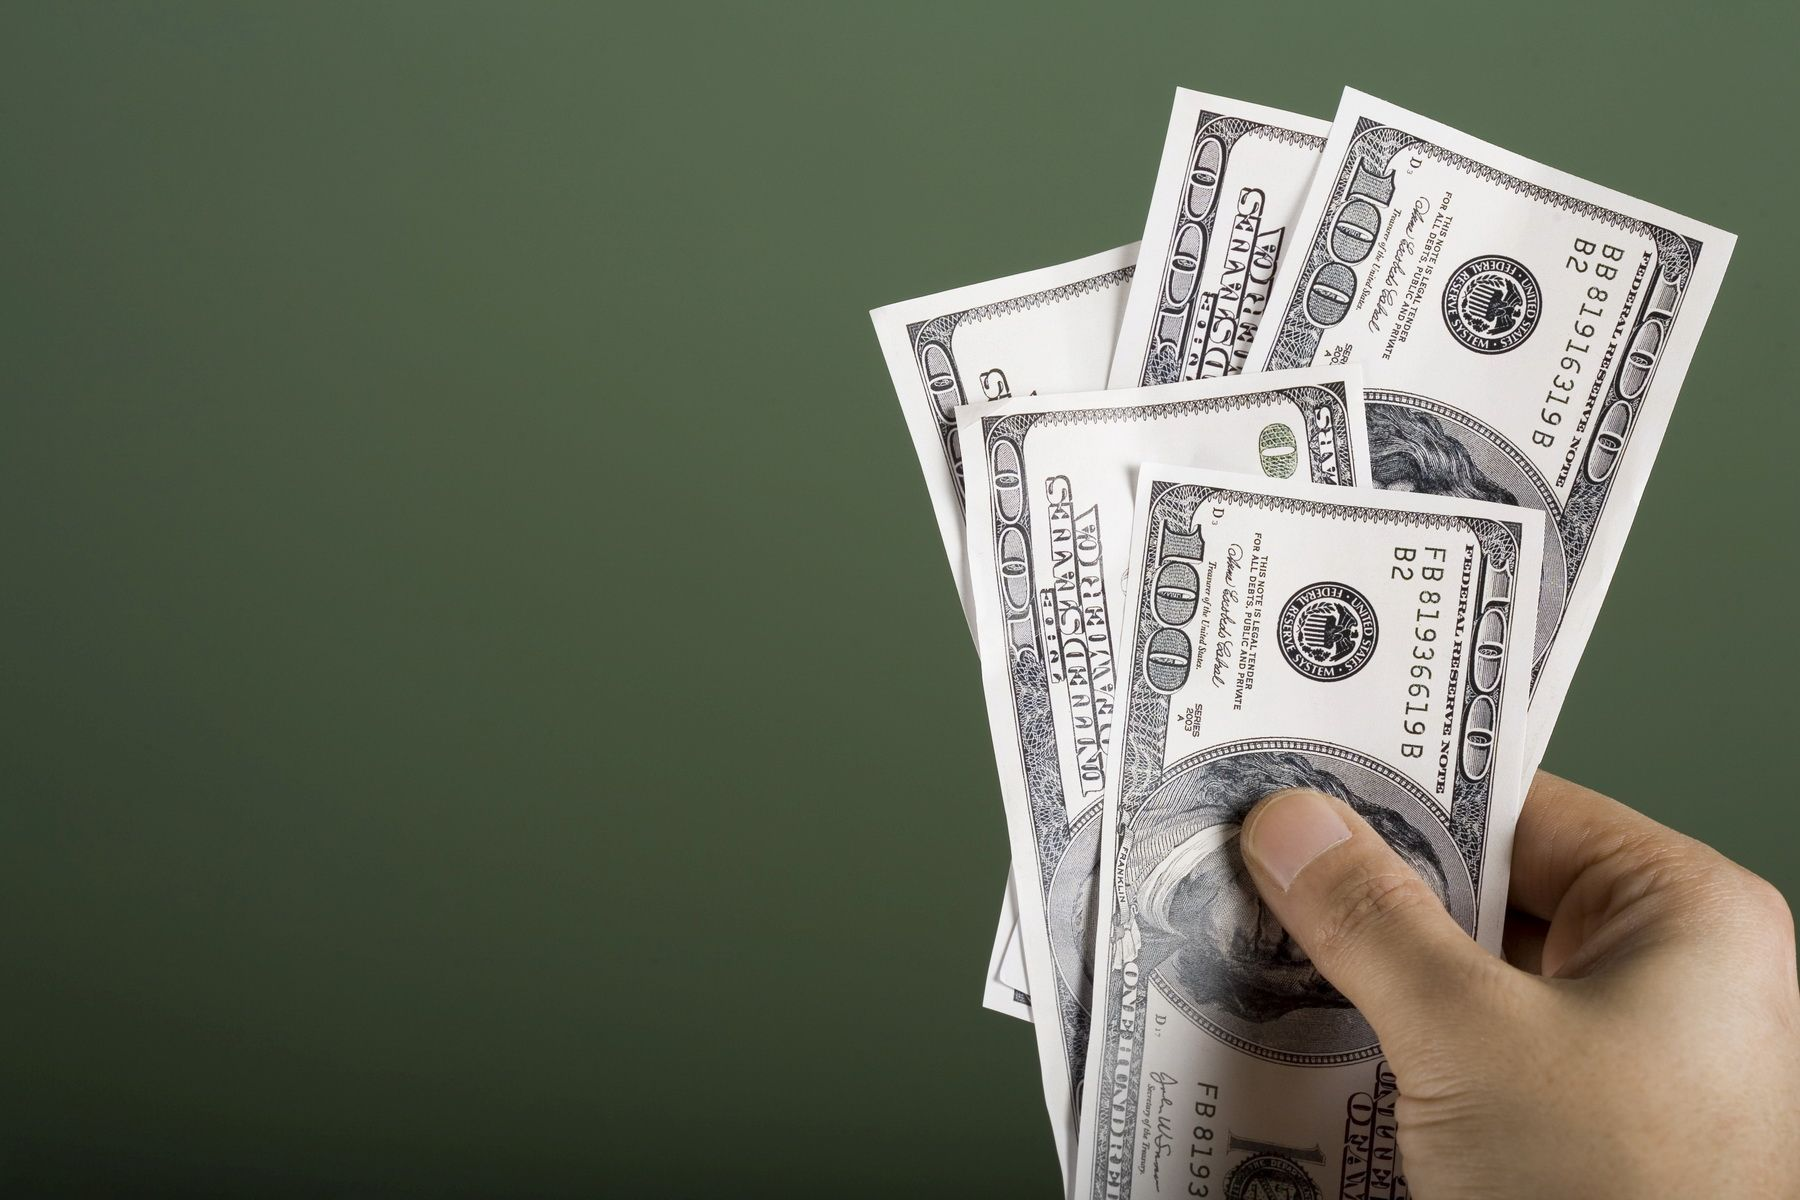

In [178]:
import time 

start_time  = time.time()

## 2. Chargement des données
Nous utilisons la bibliothèque `kagglehub` pour récupérer la version la plus récente du dataset "Loan Default Dataset".

Installation des bibliothèques nécessaires pour l'analyse de données, la gestion des datasets et le machine learning 

In [179]:
import sys
!{sys.executable} -m pip install xgboost dython missingno kagglehub pandas matplotlib seaborn scikit-learn imbalanced-learn scipy


In [180]:
import kagglehub
from pathlib import Path
import shutil
import os


# création du dossier local ( qui contiendra la base )

data_folder = Path('data')
data_folder.mkdir(exist_ok=True)

# téléchargement de la base avec Kaggle API

try : 
    path = Path(kagglehub.dataset_download("yasserh/loan-default-dataset"))
    print("Téléchargement de la dernière version réussi.")

    files = [ f for f in os.listdir(path) if f.endswith(".csv")]
    src_file = path / files[0]
    data = data_folder / "data.csv"

    shutil.copy(src_file , data )
    print(f"Fichier copié avec succès dans : {data}")

except Exception as e :
    print(f"Erreur : {e}")



Téléchargement de la dernière version réussi.
Fichier copié avec succès dans : data/data.csv


In [181]:
import pandas as pd 

df = pd.read_csv(data)
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Exploration et Nettoyage des Données

In [182]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

In [183]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [184]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

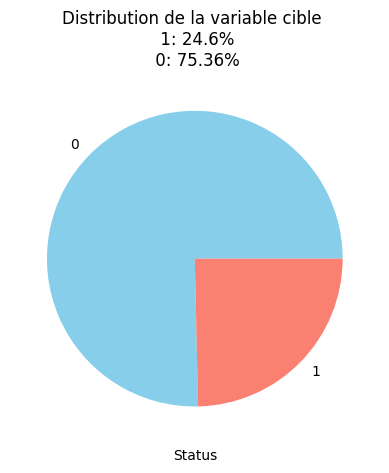

In [185]:
import matplotlib.pyplot as plt

df["Status"].value_counts().plot(kind='pie',colors=['skyblue','salmon'])
plt.title(f'Distribution de la variable cible \n 1: {(df["Status"]==1).mean()*100:.1f}%\n 0: {(df["Status"]==0).mean()*100:.2f}%')
plt.xlabel('Status')
plt.xticks(rotation=0)
plt.show()

## Les valeurs dupliquées

In [186]:
df = df.drop_duplicates()

## Création de la train_test Set

In [187]:
from sklearn.model_selection import train_test_split

X = df.drop('Status',axis=1)
y = df['Status']

X_train,X_test , y_train , y_test = train_test_split(X ,y,
                              test_size=0.2,
                              random_state=42,
                              stratify=df['Status'])
                              
X_train = X_train.reset_index(drop=True)
X_train_2 = X_train.copy()

y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)                           

print("Proportion dans le Train :\n", y_train.value_counts(normalize=True))
print("\nProportion dans le Test :\n", y_test.value_counts(normalize=True))


Proportion dans le Train :
 Status
0    0.753557
1    0.246443
Name: proportion, dtype: float64

Proportion dans le Test :
 Status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


## Les valeurs manquantes

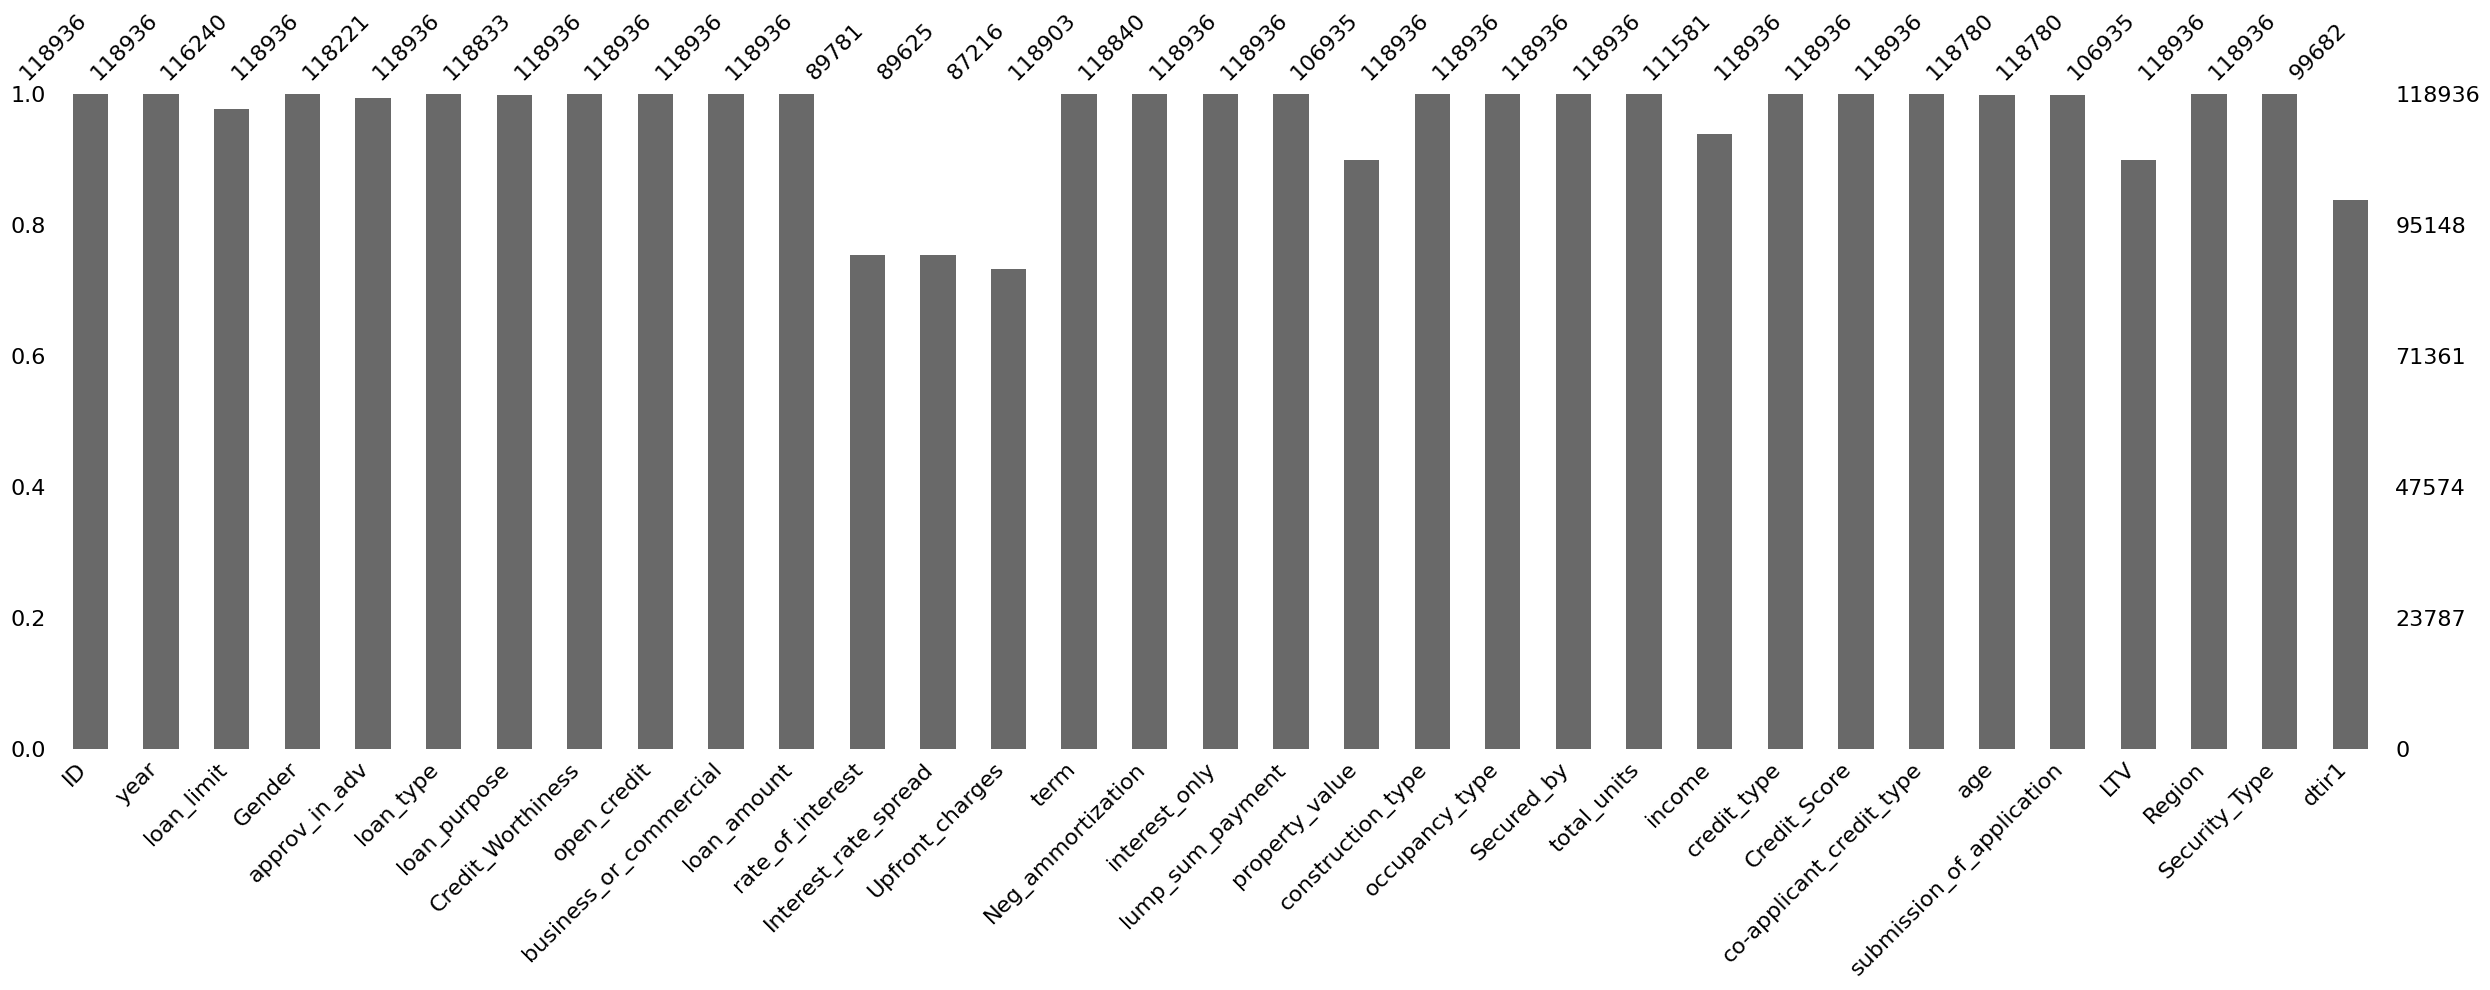

In [188]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(X_train)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [189]:
print('Pourcentage des valeurs manquantes par colonnes : \n')

missing = (X_train.isnull().mean()*100).round(2).sort_values(ascending=False) 
print (missing[ missing > 0])

Pourcentage des valeurs manquantes par colonnes : 

Upfront_charges              26.67
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.19
property_value               10.09
LTV                          10.09
income                        6.18
loan_limit                    2.27
approv_in_adv                 0.60
submission_of_application     0.13
age                           0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
dtype: float64


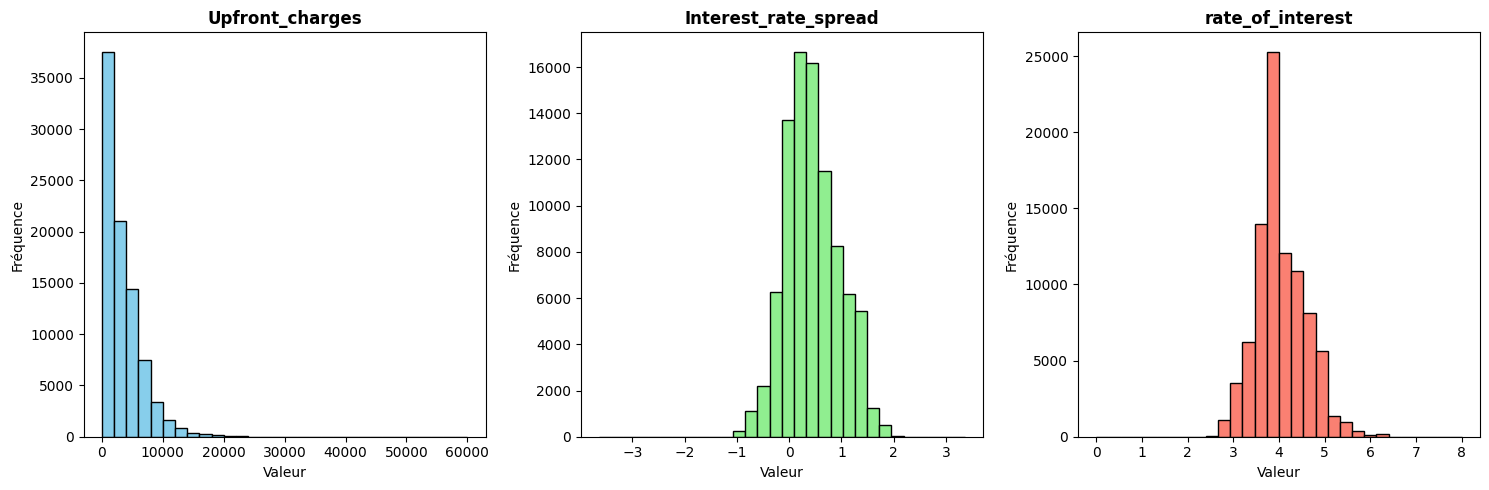

In [190]:
high_missing = ['Upfront_charges', 'Interest_rate_spread', 'rate_of_interest', 'dtir1', 'property_value', 'LTV']

import matplotlib.pyplot as plt

# Créer une figure avec 3 subplots (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Premier histogramme
axes[0].hist(X_train['Upfront_charges'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Upfront_charges', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valeur')
axes[0].set_ylabel('Fréquence')

# Deuxième histogramme
axes[1].hist(X_train['Interest_rate_spread'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Interest_rate_spread', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valeur')
axes[1].set_ylabel('Fréquence')

# Troisième histogramme
axes[2].hist(X_train['rate_of_interest'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('rate_of_interest', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valeur')
axes[2].set_ylabel('Fréquence')

# Ajuster l'espacement entre les subplots
plt.tight_layout()
plt.show()

In [191]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer


# 1. Sélection des colonnes

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

limites_basses = [-np.inf if col == 'Interest_rate_spread' else 0 for col in num_cols]

# 2. Imputation Numérique (Iterative)
numeric_imputer = IterativeImputer(max_iter=10, min_value=limites_basses)


X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[num_cols]), 
    columns=num_cols, 
    index=X_train.index
)

# 3. Imputation Catégorielle (Most Frequent)
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[cat_cols]), 
    columns=cat_cols, 
    index=X_train.index
)

# 4. Concatenation finale
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

X_train['Upfront_charges'] = X_train['Upfront_charges'].clip(lower=0)

print("Imputation réussie et index synchronisés !")

X_train.isnull().sum()

Imputation réussie et index synchronisés !


ID                           0
year                         0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
property_value               0
income                       0
Credit_Score                 0
LTV                          0
dtir1                        0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
Region                       0
Security

## Les valeurs presques constantes

In [192]:
for i in X_train.columns:

    num_uniques = X_train[i].nunique()

    if num_uniques < 3:
        print(f"--- Variable : {i} ({num_uniques} valeurs uniques) ---")
        print(X_train[i].value_counts(), '\n')

--- Variable : year (1 valeurs uniques) ---
year
2019.0    118936
Name: count, dtype: int64 

--- Variable : loan_limit (2 valeurs uniques) ---
loan_limit
cf     110936
ncf      8000
Name: count, dtype: int64 

--- Variable : approv_in_adv (2 valeurs uniques) ---
approv_in_adv
nopre    100341
pre       18595
Name: count, dtype: int64 

--- Variable : Credit_Worthiness (2 valeurs uniques) ---
Credit_Worthiness
l1    113892
l2      5044
Name: count, dtype: int64 

--- Variable : open_credit (2 valeurs uniques) ---
open_credit
nopc    118490
opc        446
Name: count, dtype: int64 

--- Variable : business_or_commercial (2 valeurs uniques) ---
business_or_commercial
nob/c    102374
b/c       16562
Name: count, dtype: int64 

--- Variable : Neg_ammortization (2 valeurs uniques) ---
Neg_ammortization
not_neg    106784
neg_amm     12152
Name: count, dtype: int64 

--- Variable : interest_only (2 valeurs uniques) ---
interest_only
not_int     113286
int_only      5650
Name: count, dtype: int

In [193]:
print(X_train["Secured_by"].value_counts(),'\n')
print(X_train["Security_Type"].value_counts(),'\n')
print(X_train["construction_type"].value_counts(),'\n')

X_train = X_train.drop(columns=['Security_Type','Secured_by','construction_type'])

# Supprimer les colonnes inutiles ( id - year )
X_train = X_train.drop(columns=['ID','year'])

drop_col = ['Secured_by','Security_Type','construction_type','ID','year']

print("==> Supprimation finie des colonnes : ID - Year - Security - construction_type")


Secured_by
home    118913
land        23
Name: count, dtype: int64 

Security_Type
direct      118913
Indriect        23
Name: count, dtype: int64 

construction_type
sb    118913
mh        23
Name: count, dtype: int64 

==> Supprimation finie des colonnes : ID - Year - Security - construction_type


## Etude de Corrélation 

## Corrélation des variables numérique avec la variable cible "Status"

In [194]:
X_train['mensualite'] = X_train['loan_amount'] / X_train['term']

corr_matrix = pd.concat([X_train.select_dtypes(include=[np.number]),y_train],axis=1).corr()

corr_matrix['Status'].reindex(corr_matrix['Status'].abs().sort_values(ascending=False).index)


Status                  1.000000
dtir1                   0.064288
income                 -0.062598
property_value         -0.041312
loan_amount            -0.039143
mensualite             -0.037475
LTV                     0.025263
Interest_rate_spread    0.022615
rate_of_interest        0.006680
Upfront_charges        -0.004544
Credit_Score            0.003124
term                   -0.001802
Name: Status, dtype: float64

## Corrélation des variables catégorielle avec la variable cible "Status"

In [195]:
from scipy.stats import chi2_contingency

def cramer_v(x,y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r , k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

results = {}
for col in X_train.select_dtypes(exclude=[np.number]):
    results[col]= cramer_v(X_train[col],y_train)

results_series = pd.Series(results)
cramers_results = results_series.reindex(results_series.abs().sort_values(ascending = False).index)
print(cramers_results)


credit_type                  0.589992
lump_sum_payment             0.182587
Neg_ammortization            0.155654
co-applicant_credit_type     0.143305
submission_of_application    0.122629
loan_type                    0.093318
business_or_commercial       0.092146
Gender                       0.084349
loan_limit                   0.052885
Region                       0.049700
age                          0.048962
loan_purpose                 0.039951
approv_in_adv                0.037715
Credit_Worthiness            0.033999
occupancy_type               0.029128
total_units                  0.026661
interest_only                0.016076
open_credit                  0.009599
dtype: float64


## Solution donnée par DeepSeek !

Corrélation avec la variable cible

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency

def correlation_avec_target_binaire(X, y):
    """
    Calcule les corrélations entre toutes les variables et une target binaire
    """
    results = []
    target_name = y.name if hasattr(y, 'name') else 'target'

    for col in X.columns:
        # 1. Traitement des variables NUMÉRIQUES
        if X[col].dtype in ['float64', 'int64']:
            # Point-biserial (Num vs Binaire)
            corr, p_val = pointbiserialr(y, X[col])
            results.append({
                'variable': col, 'type': 'numérique',
                'correlation': round(corr,3), 'p_value': p_val, 'abs_corr': abs(corr)
            })
            
        # 2. Traitement des variables CATÉGORIELLES
        else:
            contingency = pd.crosstab(X[col], y)
            # Sécurité pour les variables à modalité unique
            if min(contingency.shape) > 1:
                chi2, p_val, dof, expected = chi2_contingency(contingency)
                n = contingency.sum().sum()
                cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
                results.append({
                    'variable': col, 'type': 'catégorielle',
                    'correlation': round(cramers_v,3), 'p_value': p_val, 'abs_corr': cramers_v
                })

    df_results = (pd.DataFrame(results)).sort_values('abs_corr', ascending=False)

    return df_results.drop(columns=['abs_corr'])

# Utilisation
corr_results = correlation_avec_target_binaire(X_train, y_train)
print(corr_results)

                     variable          type  correlation        p_value
23                credit_type  catégorielle        0.590   0.000000e+00
20           lump_sum_payment  catégorielle        0.183   0.000000e+00
18          Neg_ammortization  catégorielle        0.156   0.000000e+00
24   co-applicant_credit_type  catégorielle        0.143   0.000000e+00
26  submission_of_application  catégorielle        0.123   0.000000e+00
13                  loan_type  catégorielle        0.093  4.599419e-226
17     business_or_commercial  catégorielle        0.092  7.810890e-222
11                     Gender  catégorielle        0.084  9.249511e-184
9                       dtir1     numérique        0.064  3.935115e-109
6                      income     numérique       -0.063  1.466779e-103
10                 loan_limit  catégorielle        0.053   1.550952e-74
27                     Region  catégorielle        0.050   4.960564e-64
25                        age  catégorielle        0.049   6.544

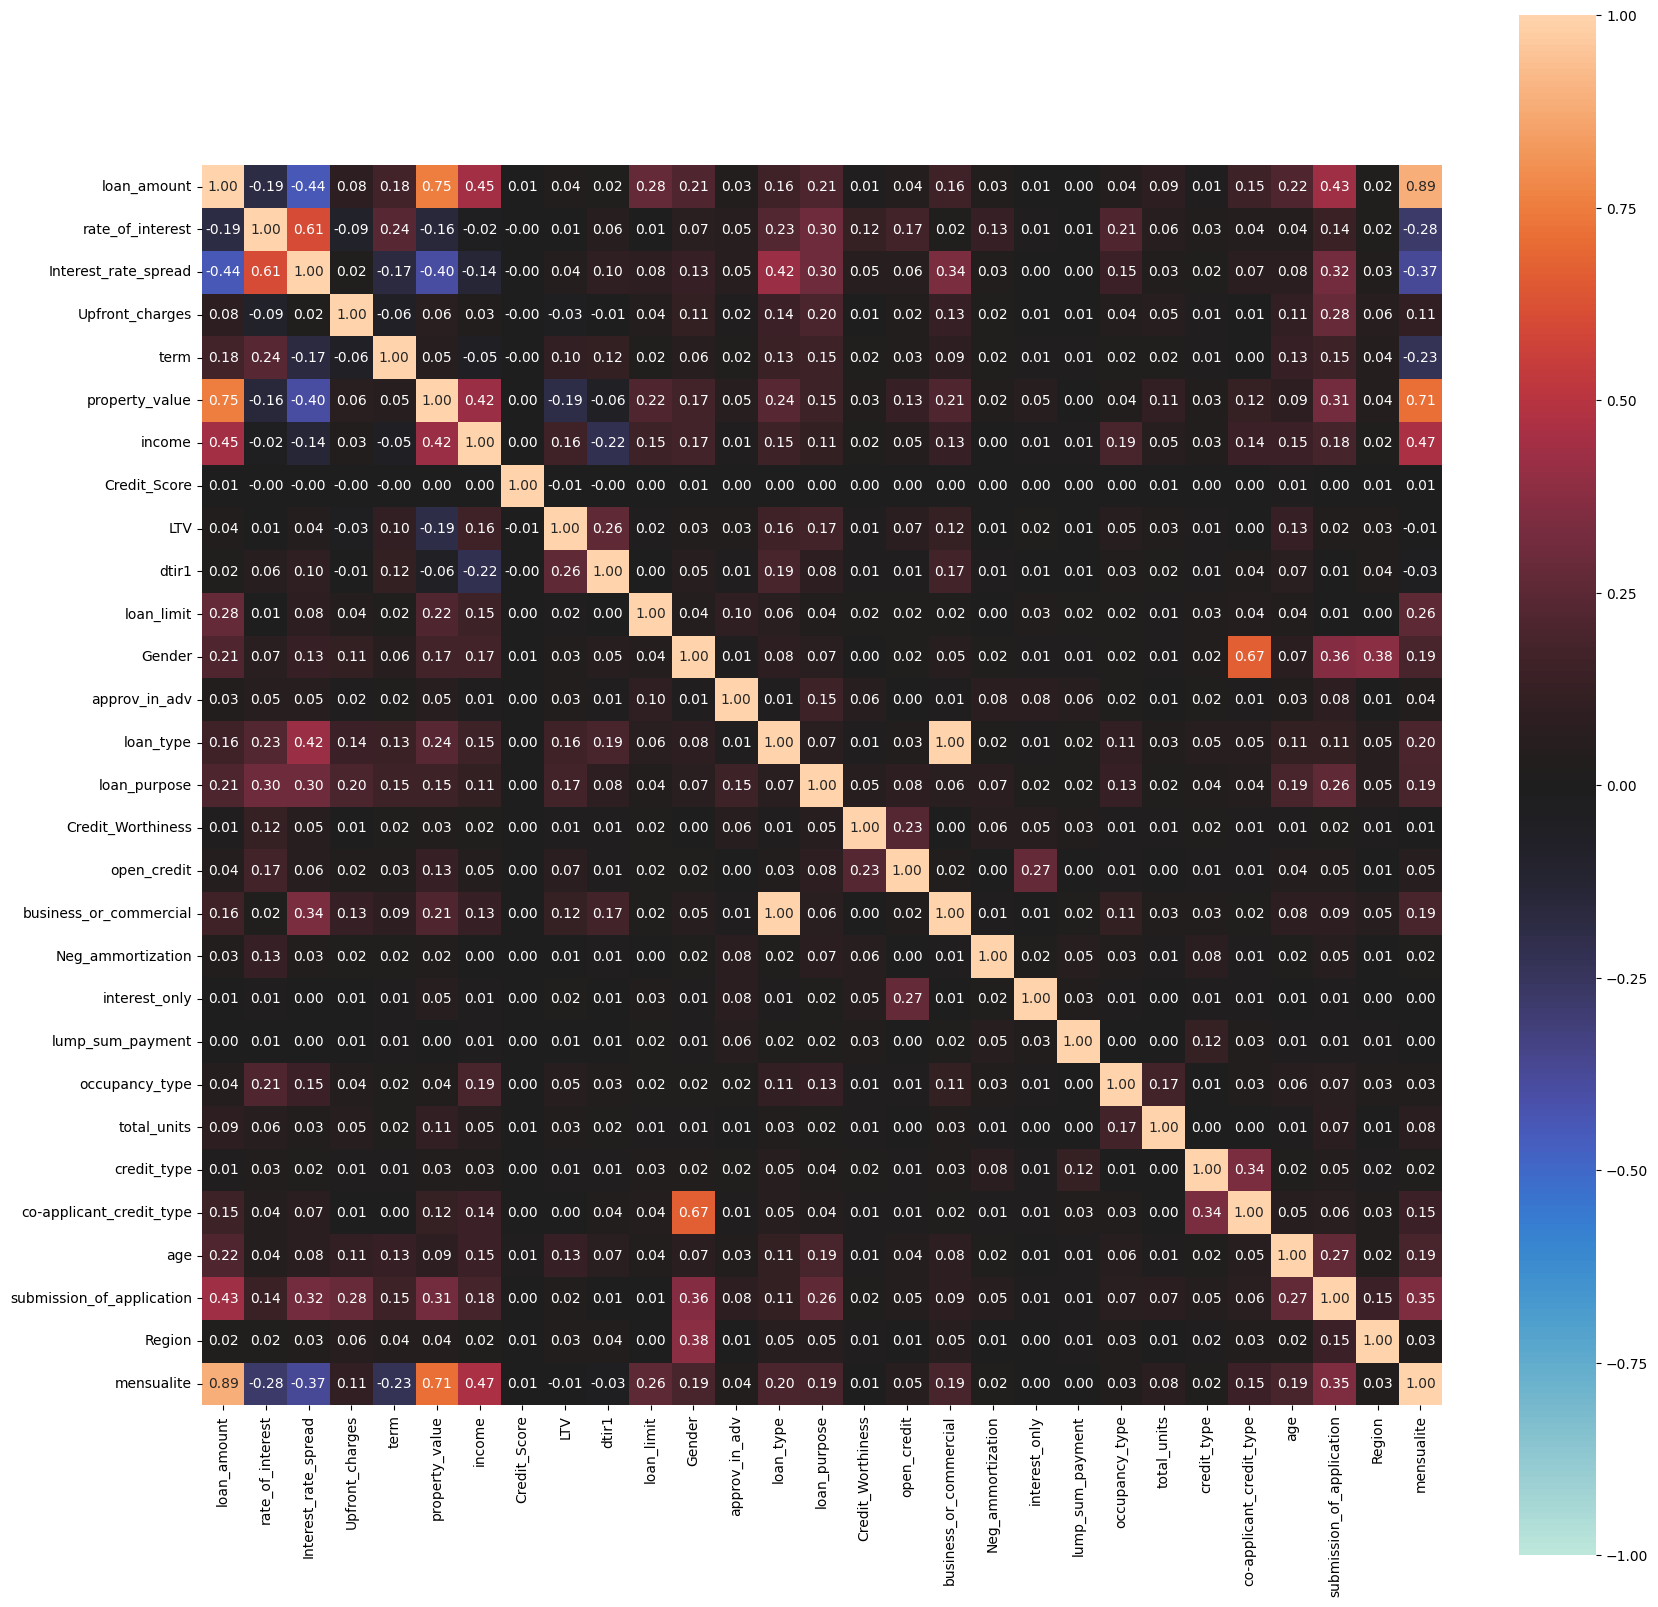

In [197]:
from dython.nominal import associations

_ = associations(X_train, figsize=(20, 20), cbar=True)

### Probléme de colinéarité parfaite (>0.9) !

In [198]:
print(f"Corrélation entre 'business_or_commercial' et 'loan_type' : {cramer_v(X_train['business_or_commercial'],X_train['loan_type'])}")
print("==> Corrélation Parfaite\n")
print("loan_type : 0.0938 (p-value: 3.5 x 10^{-285})")
print('business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})')
print("==> On supprime la variable 'business_or_commercial'.")

X_train = X_train.drop(columns=['business_or_commercial'])

drop_col += ['business_or_commercial']

Corrélation entre 'business_or_commercial' et 'loan_type' : 0.9999957959788537
==> Corrélation Parfaite

loan_type : 0.0938 (p-value: 3.5 x 10^{-285})
business_or_commercial : 0.0925 (p-value: 9.1 x 10^{-279})
==> On supprime la variable 'business_or_commercial'.


### Variables "Inutiles" ( faible Corrélation + forte P-Value )

À ce stade, nous avons choisi de conserver l'ensemble des variables. En effet, bien que certaines présentent une corrélation linéaire faible, des modèles non linéaires comme le Random Forest ou XGBoost sont capables de capturer des interactions complexes et des relations non-linéaires que les tests statistiques classiques ne décèlent pas.

### For Numerical Features (ANOVA F-test)

In [199]:
import pandas as pd
from sklearn.feature_selection import f_classif
import numpy as np

# 1. Identify numerical columns from the current X_train
# We exclude 'mensualite' if we want to check against the original set, 
# but since it's in X_train, we use X_train and y_train to match indices.
num_cols = X_train.select_dtypes(include=['number']).columns

# 2. Compute ANOVA F-value and p-value using the processed training data
f_scores, p_values = f_classif(X_train[num_cols], y_train)

# 3. Create a summary table
anova_stats = pd.DataFrame({
    'Feature': num_cols,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

print("--- ANOVA Statistics (Numerical Features) ---")
display(anova_stats)

--- ANOVA Statistics (Numerical Features) ---


,Feature,F-Score,p-value
9,dtir1,493.591895,3.935115e-109
6,income,467.884176,1.466779e-103
5,property_value,203.325963,4.286755e-46
0,loan_amount,182.507295,1.474704e-41
10,mensualite,167.258963,3.116615e-38
8,LTV,75.954273,2.939438e-18
2,Interest_rate_spread,60.859907,6.177885e-15
1,rate_of_interest,5.307766,2.123228e-02
3,Upfront_charges,2.455951,1.170829e-01
7,Credit_Score,1.160560,2.813517e-01


### for Categorical Features (Chi-Square Test) 

In [200]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OrdinalEncoder

# 1. Identify categorical columns in X_train
cat_cols = X_train_2.select_dtypes(include=['object', 'category']).columns

# 2. Chi-Square requires numerical input. We temporarily encode categories.
# We use X_train_2 (raw categories) and handle missing values for the test
temp_df = X_train_2[cat_cols].fillna("UNKNOWN")
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(temp_df)

# 3. Compute Chi-Square scores
chi_scores, chi_p_values = chi2(X_encoded, y_train)

# 4. Create a summary table
chi_stats = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2-Score': chi_scores,
    'p-value': chi_p_values
}).sort_values(by='Chi2-Score', ascending=False)

print("\n--- Chi-Square Statistics (Categorical Features) ---")
display(chi_stats)


--- Chi-Square Statistics (Categorical Features) ---


,Feature,Chi2-Score,p-value
15,credit_type,1593.118612,0.000000e+00
16,co-applicant_credit_type,1225.174971,2.061212e-268
3,loan_type,391.701413,3.527603e-87
19,Region,388.659902,1.620389e-86
17,age,385.540214,7.740914e-86
1,Gender,218.186952,2.248345e-49
18,submission_of_application,211.765924,5.657164e-48
7,business_or_commercial,140.850336,1.734877e-32
8,Neg_ammortization,139.586598,3.278054e-32
5,Credit_Worthiness,132.981575,9.125479e-31


## QQs Visualisations

In [201]:
# Création d'un dataset temporaire pour la visualisation

train_eda = X_train.copy()
train_eda['Status'] = y_train.values

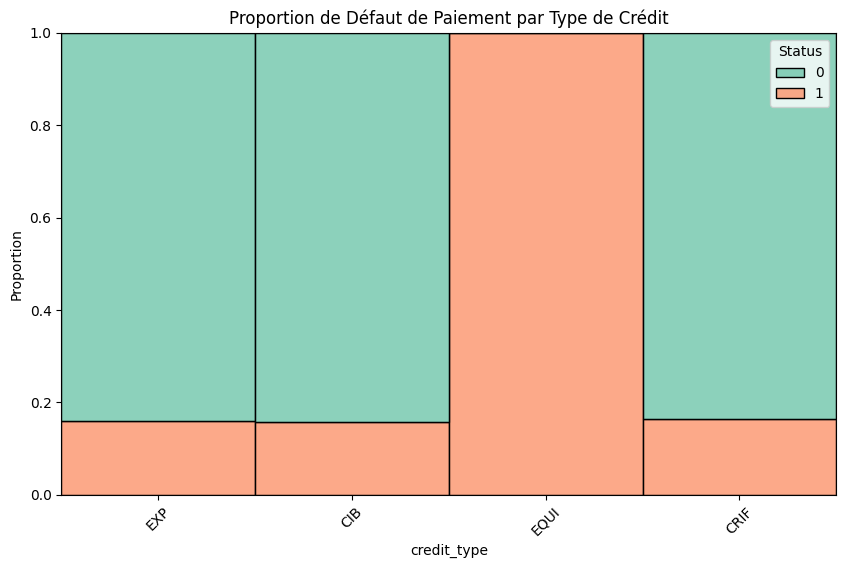

In [202]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_eda, x='credit_type', hue='Status', multiple="fill", palette='Set2')
plt.title("Proportion de Défaut de Paiement par Type de Crédit")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [203]:
X_train['credit_type'].value_counts()

credit_type
CIB     38567
CRIF    35111
EXP     33100
EQUI    12158
Name: count, dtype: int64

- CIB (Credit Information Bureau) : Un bureau de données qui centralise l'historique de crédit des emprunteurs pour évaluer leur solvabilité avant l'octroi d'un prêt.

- CRIF (Centrale de Risques Financiers) : Un système international spécialisé dans la gestion du risque de crédit et les solutions de Business Information pour le secteur bancaire.

- EXP (Experian) : L'un des trois plus grands bureaux de crédit mondiaux, fournissant des scores de risque basés sur l'historique de paiement et l'endettement.

- EQUI (Equifax) : Une agence globale d'évaluation du crédit qui regroupe les données financières pour produire des rapports de solvabilité utilisés par les prêteurs.

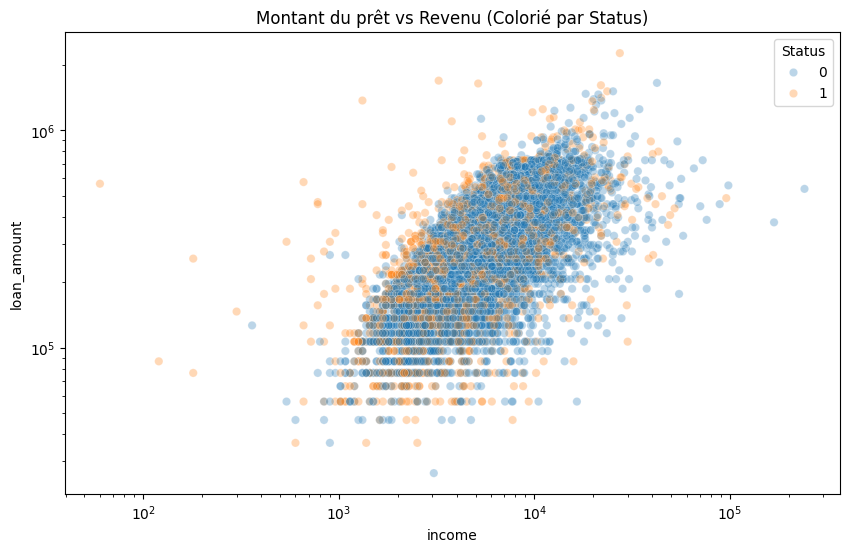

In [204]:
plt.figure(figsize=(10, 6))
# On utilise un échantillon si le dataset est trop gros pour éviter que les points ne se chevauchent trop
sns.scatterplot(data=train_eda.sample(min(10000, len(train_eda))), 
                x='income', y='loan_amount', hue='Status', alpha=0.3)
plt.title("Montant du prêt vs Revenu (Colorié par Status)")
plt.xscale('log') # Souvent nécessaire pour l'argent
plt.yscale('log')
plt.show()

## Gestion des Attributs Textuels et Catégoriels 

In [205]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Modalitées des variables catégoriels")

X_train.select_dtypes(exclude=['float64', 'int64']).nunique()

Modalitées des variables catégoriels


loan_limit                   2
Gender                       4
approv_in_adv                2
loan_type                    3
loan_purpose                 4
Credit_Worthiness            2
open_credit                  2
Neg_ammortization            2
interest_only                2
lump_sum_payment             2
occupancy_type               3
total_units                  4
credit_type                  4
co-applicant_credit_type     2
age                          7
submission_of_application    2
Region                       4
dtype: int64

### La stratégie d'encodage 

In [206]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

ordinal_encoder = OrdinalEncoder()
onehot_encoder =OneHotEncoder(sparse_output=False, handle_unknown='ignore')

all_cat = X_train.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

ordinal_feat = ['age','Credit_Worthiness']
onehot_feat = [col for col in all_cat if col not in ordinal_feat]

X_train_ohe = pd.DataFrame(
    onehot_encoder.fit_transform(X_train[onehot_feat]),
    columns=onehot_encoder.get_feature_names_out(onehot_feat),
    index=X_train.index
)
X_train_ord = pd.DataFrame(
    ordinal_encoder.fit_transform(X_train[ordinal_feat]),
    columns=ordinal_feat,
    index=X_train.index
)

X_train_num = X_train.select_dtypes(include=['float64', 'int64'])
X_train = pd.concat([X_train_num, X_train_ohe, X_train_ord], axis=1)

print(f"Dimensions finales : {X_train.shape}")
type(X_train)


Dimensions finales : (118936, 55)


pandas.DataFrame

## Distrubition des variables numériques

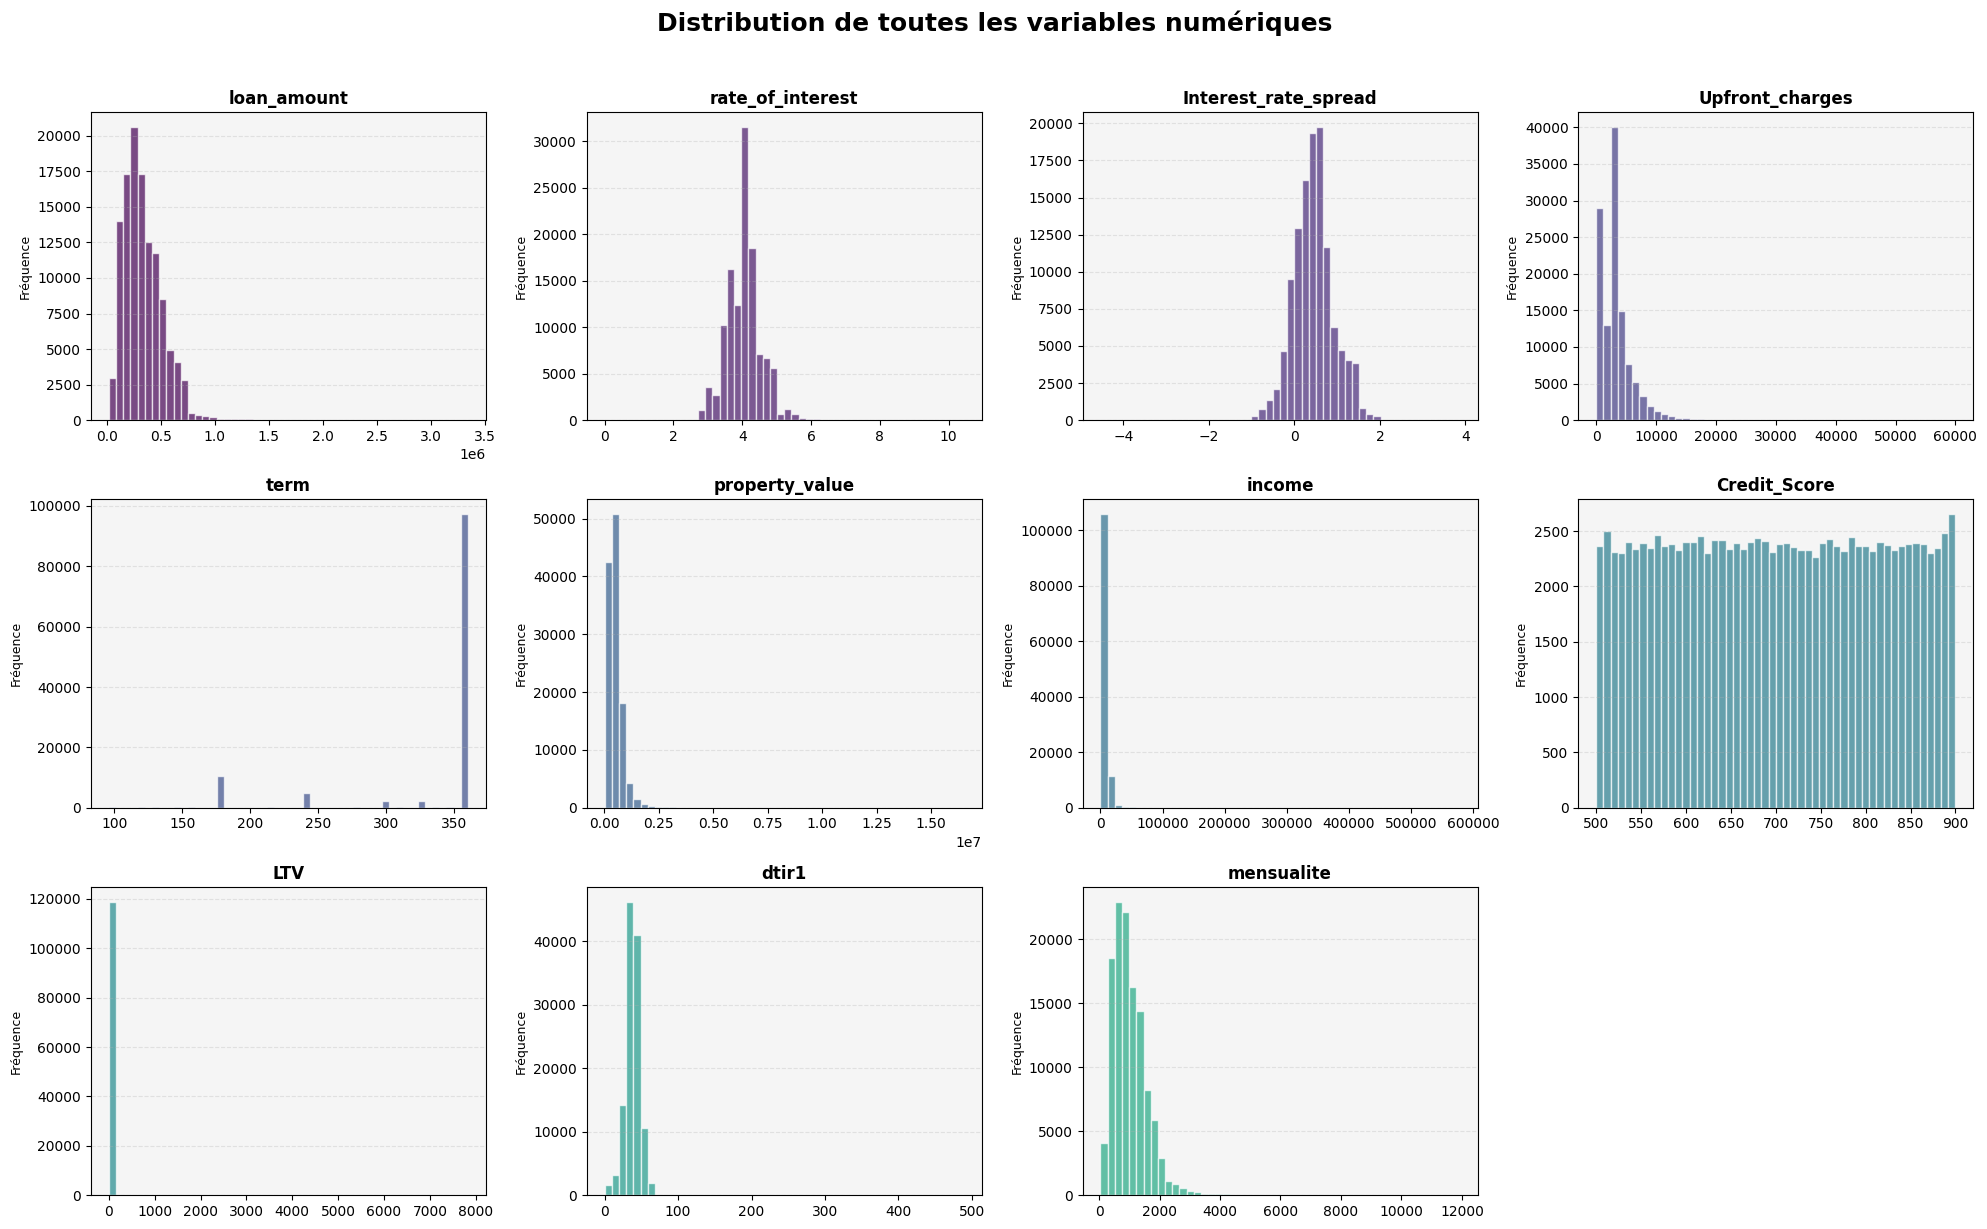

In [207]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sélectionner uniquement les colonnes numériques
cols_num = num_cols
n_cols = len(cols_num)

# 2. Calculer le nombre de lignes/colonnes pour la grille
n_subplot_cols = 4
n_subplot_rows = (n_cols + n_subplot_cols - 1) // n_subplot_cols

# 3. Créer UNE SEULE figure
fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols, figsize=(20, 4 * n_subplot_rows))
axes = axes.flatten() # Aplatir pour itérer facilement

# 4. Palette de couleurs (une couleur différente par plot)
colors = plt.cm.viridis(np.linspace(0, 0.6, n_cols))

# 5. Boucle pour tracer chaque histogramme manuellement
for i, col in enumerate(cols_num):
    ax = axes[i]
    X_train[col].hist(ax=ax, bins=50, color=colors[i], edgecolor='white', alpha=0.7, grid=False)
    
    # Personnalisation
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_facecolor('#f5f5f5')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylabel('Fréquence', fontsize=9)

# 6. Supprimer les subplots vides si nécessaire
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution de toutes les variables numériques', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### transformation

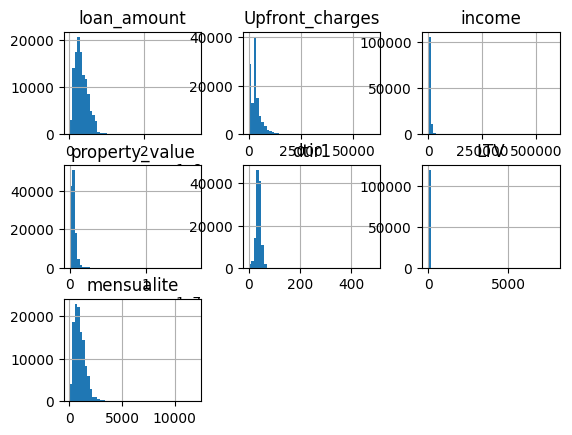

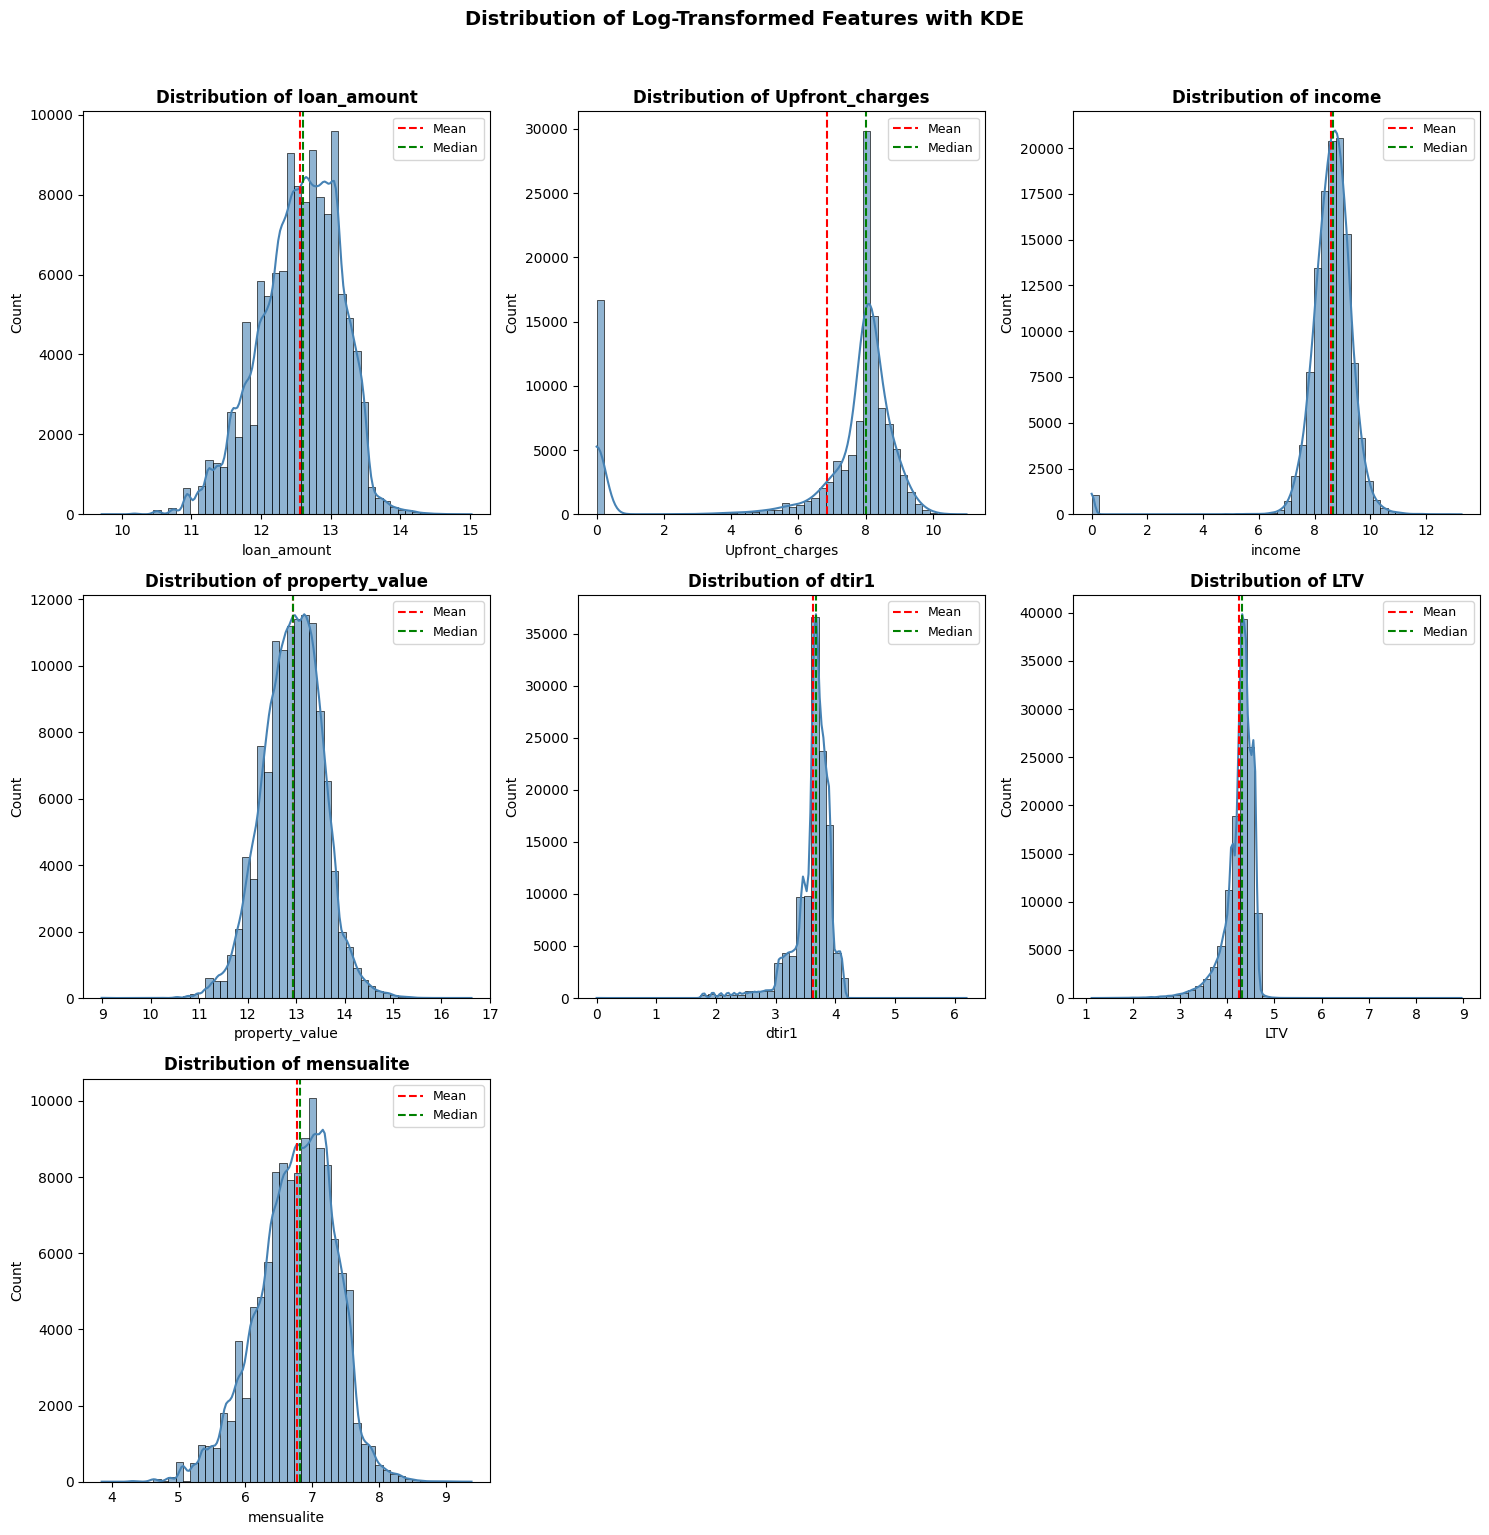

In [208]:
from sklearn.preprocessing import FunctionTransformer
import math

log_trans_col = ['loan_amount','Upfront_charges','income','property_value','dtir1','LTV','mensualite']
X_train[log_trans_col].hist(bins = 50)

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)

X_train[log_trans_col] = log_transformer.fit_transform(X_train[log_trans_col])



""" -------- Code for better visualization -------- """


n_features = len(log_trans_col)
n_cols_grid = 3
n_rows_grid = math.ceil(n_features / n_cols_grid)

# 3. Création de la figure qui s'adapte
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 5 * n_rows_grid))
axes = axes.ravel()

# 4. Ta boucle intacte
for idx, col in enumerate(log_trans_col):
    sns.histplot(data=X_train, x=col, bins=50, kde=True, ax=axes[idx], 
                 color='steelblue', edgecolor='black', alpha=0.6)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].axvline(x=X_train[col].mean(), color='red', linestyle='--', 
                      linewidth=1.5, label='Mean')
    axes[idx].axvline(x=X_train[col].median(), color='green', linestyle='--', 
                      linewidth=1.5, label='Median')
    axes[idx].legend(fontsize=9)

# 5. On efface les cases vides en trop (les cases 8 et 9)
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Log-Transformed Features with KDE', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pour la variable "term"

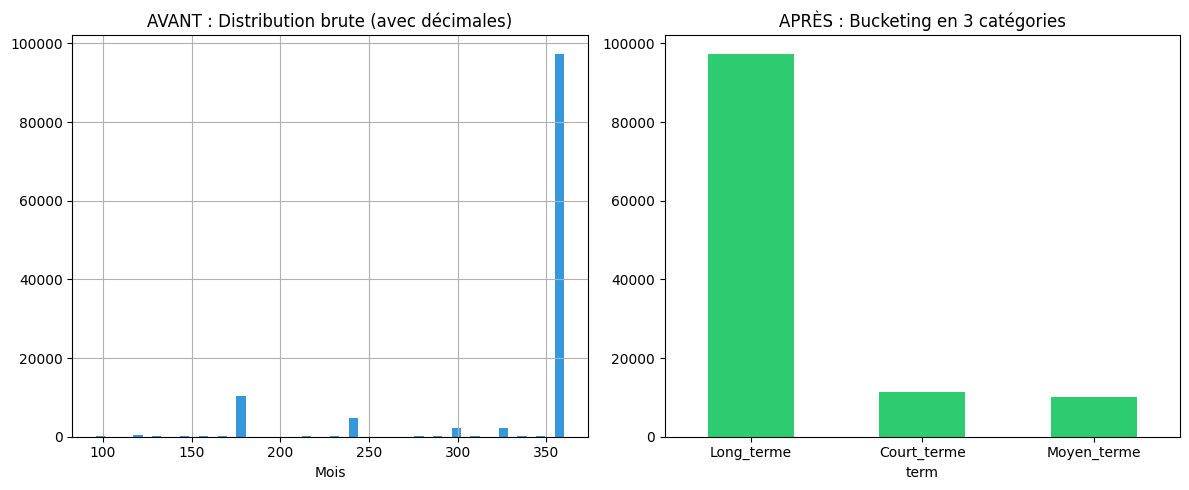

In [209]:
def bucketize_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']

    X_binned = pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str).to_frame()
    return X_binned

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
X_train['term'].hist(bins=50, color='#3498db')
plt.title("AVANT : Distribution brute (avec décimales)")
plt.xlabel("Mois")

term_transf = FunctionTransformer(bucketize_term)
X_train["term"] = term_transf.fit_transform(X_train[['term']])

plt.subplot(1, 2, 2)
X_train['term'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title("APRÈS : Bucketing en 3 catégories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [210]:
term_ohe = onehot_encoder.fit_transform(X_train[['term']])
term_col = onehot_encoder.get_feature_names_out(['term'])

term_encoded = pd.DataFrame(term_ohe, columns=term_col, index=X_train.index)
X_train = pd.concat([X_train, term_encoded], axis=1)
X_train = X_train.drop(columns=['term'])

print('Encodage terminé !')


Encodage terminé !


### Feature Scaling

In [211]:
from sklearn.preprocessing import StandardScaler

cols_num.remove("term")

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])

print("Scaling terminé !")


Scaling terminé !


## Résultat finale ! 

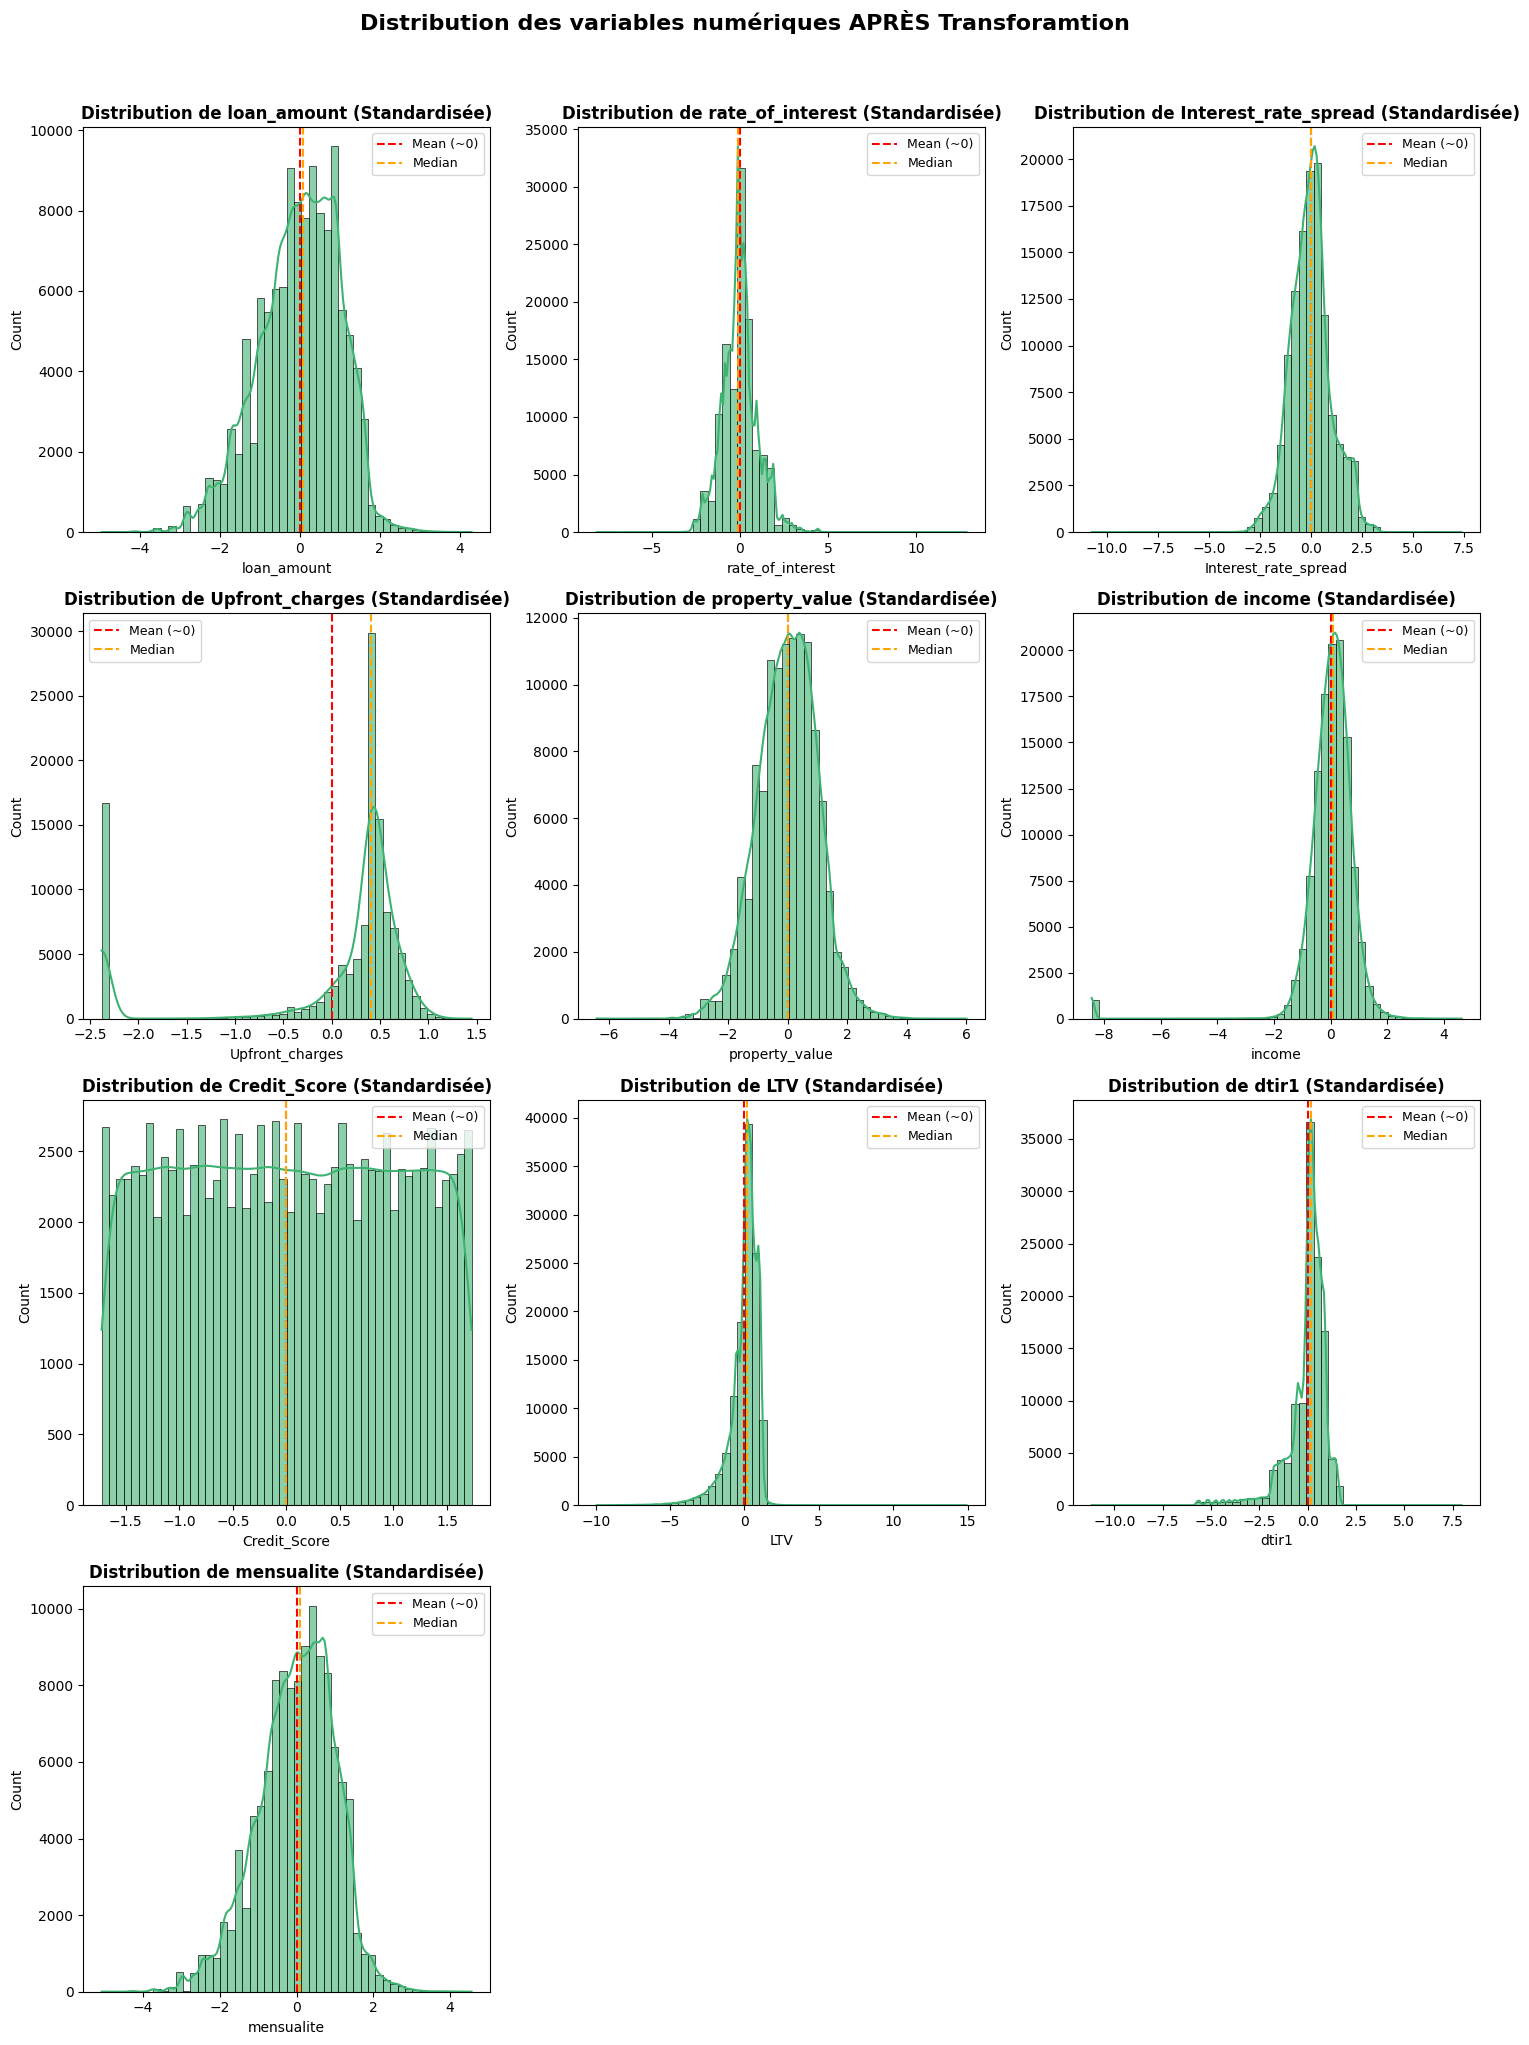

In [212]:
# 1. Calcul automatique de la taille de la grille selon le nombre de colonnes
n_features = len(cols_num)
n_cols_grid = 3
n_rows_grid = math.ceil(n_features / n_cols_grid)

# 2. Création de la figure (la hauteur s'adapte au nombre de lignes)
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 5 * n_rows_grid))
axes = axes.ravel() # Aplatit la grille pour pouvoir boucler dessus facilement

# 3. Boucle sur les colonnes numériques
for idx, col in enumerate(cols_num):
    # Tracé de l'histogramme avec KDE
    sns.histplot(data=X_train, x=col, bins=50, kde=True, ax=axes[idx], 
                 color='mediumseagreen', edgecolor='black', alpha=0.6)
    
    axes[idx].set_title(f'Distribution de {col} (Standardisée)', fontsize=12, fontweight='bold')
    
    # Ajout des lignes de Moyenne et Médiane
    axes[idx].axvline(x=X_train[col].mean(), color='red', linestyle='--', 
                      linewidth=1.5, label='Mean (~0)')
    axes[idx].axvline(x=X_train[col].median(), color='orange', linestyle='--', 
                      linewidth=1.5, label='Median')
    axes[idx].legend(fontsize=9)

# 4. Nettoyage : cacher les cases vides si le nombre de features n'est pas un multiple de 3
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

# 5. Titre global et affichage
plt.suptitle('Distribution des variables numériques APRÈS Transforamtion', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Pipeline de Preprocessing

In [213]:
import warnings
warnings.filterwarnings('ignore')

In [214]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn import set_config


set_config(transform_output="pandas")

# Helper functions for the pipeline
def calculate_mensualite(X):
    # Calculation: loan_amount / term
    res = pd.DataFrame(X.iloc[:, 0] / X.iloc[:, 1], columns=["mensualite"])
    return res

def bucket_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']
    return pd.DataFrame(pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str), columns=["term"])

# Define feature groups based on raw data
log_cols = ['loan_amount', 'income', 'property_value', 'dtir1', 'LTV']
num_standard_cols = ['Credit_Score']
ordinal_feat = ['age', 'Credit_Worthiness']
cat_nominales = ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'open_credit', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'total_units', 'credit_type', 'co-applicant_credit_type', 'submission_of_application', 'Region']

# Pipelines for individual features
mensualite_pipeline = make_pipeline(
    FunctionTransformer(calculate_mensualite),
    FunctionTransformer(np.log1p),
    StandardScaler()
)

term_pipeline = make_pipeline(
    FunctionTransformer(bucket_term),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

# Second Stage: Feature Engineering and Scaling
# We set verbose_feature_names_out=False to keep original column names from the previous step
preprocessing = ColumnTransformer([
    ("mensualite", mensualite_pipeline, ["loan_amount", "term"]),
    ("log_num", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), log_cols),
    ("term_bucket", term_pipeline, ["term"]),
    ("num_standard", StandardScaler(), num_standard_cols),
    ("ordinal", OrdinalEncoder(), ordinal_feat),
    ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_nominales)
], remainder="drop", verbose_feature_names_out=False)

# First Stage: Imputation
impute_step = ColumnTransformer([
    ('num_impute', IterativeImputer(max_iter=10, random_state=42, min_value=0), log_cols + num_standard_cols + ['term']),
    ('cat_impute', SimpleImputer(strategy='most_frequent'), ordinal_feat + cat_nominales)
], remainder='drop', verbose_feature_names_out=False)

# Complete pipeline
full_pipeline = make_pipeline(
    impute_step,
    preprocessing
)

In [215]:
"""
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer

from sklearn import set_config
set_config(transform_output="pandas")

def calculate_mensualite(X):
    # X.iloc[:, 0] = loan_amount | X.iloc[:, 1] = term
    return pd.DataFrame(X.iloc[:, 0] / X.iloc[:, 1], columns=["mensualite"])

def clip_and_log(X):
    # Bloque les valeurs négatives à 0 minimum, puis applique le log
    X_clipped = np.clip(X, a_min=0, a_max=None)
    return np.log1p(X_clipped)

def bucket_term(X):
    bins = [0, 180, 359, np.inf]
    labels = ['Court_terme', 'Moyen_terme', 'Long_terme']
    # On transforme en String pour le OneHotEncoder qui suit
    return pd.DataFrame(pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str), columns=["term"])

num_pipeline = make_pipeline(
    StandardScaler()
)

log_pipeline = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

upfront_pipeline = make_pipeline(
    FunctionTransformer(clip_and_log, feature_names_out="one-to-one"),
    StandardScaler()
)

mensualite_pipeline = make_pipeline(
    FunctionTransformer(calculate_mensualite, feature_names_out=lambda self, names: ["mensualite"]),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

term_pipeline = make_pipeline(
    FunctionTransformer(bucket_term, feature_names_out=lambda self, names: ["term"]),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

ordinal_pipeline = make_pipeline(
    OrdinalEncoder()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

log_cols = ['loan_amount', 'income', 'property_value', 'dtir1', 'LTV']
num_standard_cols = ['Credit_Score', 'Interest_rate_spread', 'rate_of_interest']
ordinal_feat = ['age', 'Credit_Worthiness']

cat_cols_brut = X.select_dtypes(exclude=[np.number]).columns.tolist()
cat_nominales = [col for col in cat_cols_brut if col not in ordinal_feat and col not in drop_col]

num_cols_all = log_cols + num_standard_cols + ['Upfront_charges', 'term', 'loan_amount']
limites_basses = [-np.inf if col == 'interest_rate_spread' else 0 for col in num_cols_all]

cat_cols_all = ordinal_feat + cat_nominales


imputer_step = ColumnTransformer(
    transformers=[
        ('num_imputer', IterativeImputer(max_iter=10, random_state=42,min_value=limites_basses), num_cols_all),
        ('cat_imputer', SimpleImputer(strategy='most_frequent'), cat_cols_all)
    ],
    remainder='passthrough'
)

preprocessing = ColumnTransformer([
    ("mensualite", mensualite_pipeline, ["loan_amount", "term"]),
    ("upfront", upfront_pipeline, ["Upfront_charges"]),
    ("log_num", log_pipeline, log_cols),
    ("term_bucket", term_pipeline, ["term"]),
    ("num_standard", num_pipeline, num_standard_cols),
    ("ordinal", ordinal_pipeline, ordinal_feat),
    ("categorical", cat_pipeline, cat_nominales)
], remainder="drop")

full_pipeline = make_pipeline(
    imputer_step,
    preprocessing
)
"""

'\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.compose import make_column_transformer\n\nfrom sklearn import set_config\nset_config(transform_output="pandas")\n\ndef calculate_mensualite(X):\n    # X.iloc[:, 0] = loan_amount | X.iloc[:, 1] = term\n    return pd.DataFrame(X.iloc[:, 0] / X.iloc[:, 1], columns=["mensualite"])\n\ndef clip_and_log(X):\n    # Bloque les valeurs négatives à 0 minimum, puis applique le log\n    X_clipped = np.clip(X, a_min=0, a_max=None)\n    return np.log1p(X_clipped)\n\ndef bucket_term(X):\n    bins = [0, 180, 359, np.inf]\n    labels = [\'Court_terme\', \'Moyen_terme\', \'Long_terme\']\n    # On transforme en String pour le OneHotEncoder qui suit\n    return pd.DataFrame(pd.cut(X.iloc[:, 0], bins=bins, labels=labels).astype(str), columns=["term"])\n\nnum_pipeline = make_pipeline(\n    StandardScaler()\n)\n\nlog_pipeline = make_pipeline(\n    FunctionTransformer(np.log1p, feature_names_out="one-to-o

#### PCA ( Elle n'est pas prise en compte par la suite malgrés on a une bonne réduction )

In [216]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 0.95)

pca.fit(X_train)

n_final = pca.n_components_
n_original = X_train.shape[1]

print(f"Dimensions originales : {n_original}")
print(f"Dimensions après PCA (95% variance) : {n_final}")
print(f"Réduction de {((n_original - n_final) / n_original) * 100:.1f}%")

Dimensions originales : 57
Dimensions après PCA (95% variance) : 23
Réduction de 59.6%


## SMOTE

In [217]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :")
print(y_train.value_counts())
print("\nAprès SMOTE :")
print(y_train_resampled.value_counts())

Avant SMOTE :
Status
0    89625
1    29311
Name: count, dtype: int64

Après SMOTE :
Status
0    89625
1    89625
Name: count, dtype: int64


## Training

In [218]:
X_train_resampled = X_train_resampled.drop(columns=["Interest_rate_spread","Upfront_charges","rate_of_interest"])

X_train = X_train.drop(columns=["Interest_rate_spread","Upfront_charges","rate_of_interest"])


In [219]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

ling_reg = LinearRegression()
ling_reg.fit(X_train_resampled, y_train_resampled)

y_train_pred = ling_reg.predict(X_train_resampled)
y_train_pred_class = (y_train_pred >= 0.5).astype(int)

print("\n--- Rapport de Classification : Linear Regression (Train) ---")
print(classification_report(y_train_resampled, y_train_pred_class))


--- Rapport de Classification : Linear Regression (Train) ---
              precision    recall  f1-score   support

           0       0.70      0.93      0.79     89625
           1       0.89      0.59      0.71     89625

    accuracy                           0.76    179250
   macro avg       0.79      0.76      0.75    179250
weighted avg       0.79      0.76      0.75    179250



In [220]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression()
log_reg.fit(X_train_resampled, y_train_resampled)

y_train_pred = log_reg.predict(X_train_resampled)


print("\n--- Rapport de Classification : Logistic Regression (Train) ---")
print(classification_report(y_train_resampled, y_train_pred_class))


--- Rapport de Classification : Logistic Regression (Train) ---
              precision    recall  f1-score   support

           0       0.70      0.93      0.79     89625
           1       0.89      0.59      0.71     89625

    accuracy                           0.76    179250
   macro avg       0.79      0.76      0.75    179250
weighted avg       0.79      0.76      0.75    179250



In [221]:
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1,random_state=42)
svm.fit(X_train_resampled,y_train_resampled)

y_svm_pred = svm.predict(X_train_resampled)

print("\n--- Rapport de Classification : LinearSVC (Train) ---")
print(classification_report(y_train_resampled, y_svm_pred))


--- Rapport de Classification : LinearSVC (Train) ---
              precision    recall  f1-score   support

           0       0.72      0.90      0.80     89625
           1       0.87      0.64      0.74     89625

    accuracy                           0.77    179250
   macro avg       0.79      0.77      0.77    179250
weighted avg       0.79      0.77      0.77    179250



In [222]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,
                            n_jobs=-1)
rfc.fit(X_train_resampled,y_train_resampled)

y_rf_pred = rfc.predict(X_train_resampled)

print("--- Rapport de Classification : RANDOM FOREST (Train) ---")
print(classification_report(y_train_resampled, y_rf_pred))

--- Rapport de Classification : RANDOM FOREST (Train) ---
              precision    recall  f1-score   support

           0       0.79      0.96      0.87     89625
           1       0.95      0.74      0.83     89625

    accuracy                           0.85    179250
   macro avg       0.87      0.85      0.85    179250
weighted avg       0.87      0.85      0.85    179250



### Cross-validation

In [223]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=100,
                               max_depth=15,
                               random_state=42,
                               n_jobs=-1)

scores = cross_val_score(rf_cv , X_train_resampled , y_train_resampled,
                         cv = 5,
                         scoring= "recall")

print(f"Scores de Recall par fold : {scores}")
print(f"Moyenne du Recall : {scores.mean():.4f}")
print(f"Écart-type (Stabilité) : {scores.std():.4f}")

Scores de Recall par fold : [0.62086471 0.71062762 0.85322176 0.85986053 0.85947001]
Moyenne du Recall : 0.7808
Écart-type (Stabilité) : 0.0982


### Cross-validation : solution de Gemini

In [224]:
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from sklearn.model_selection import cross_val_score

# 1. On crée un pipeline qui fait SMOTE puis Random Forest
cv_pipeline = make_imb_pipeline(
    SMOTE(random_state=42), 
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
)

# 2. On lance la CV sur les données nettoyées AVANT SMOTE (X_train_clean)
vrais_scores = cross_val_score(
    cv_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring="recall"
)

print(f"Vrais scores de Recall par fold : {vrais_scores}")
print(f"Vraie moyenne du Recall : {vrais_scores.mean():.4f}")
print(f"Écart-type (Stabilité) : {vrais_scores.std():.4f}")

Vrais scores de Recall par fold : [0.62493604 0.62436029 0.62282497 0.62146025 0.61958376]
Vraie moyenne du Recall : 0.6226
Écart-type (Stabilité) : 0.0019


In [225]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,

    # device = "cuda",
    tree_method = "hist",

    subsample = 0.8,
    colsample_bytree = 0.8,

    random_state = 42,
    eval_metric = 'logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_train_resampled)

print("--- Résultats XGBoost ---")
print(classification_report(y_train_resampled, y_pred_xgb))

--- Résultats XGBoost ---
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     89625
           1       0.98      0.87      0.92     89625

    accuracy                           0.93    179250
   macro avg       0.93      0.93      0.93    179250
weighted avg       0.93      0.93      0.93    179250



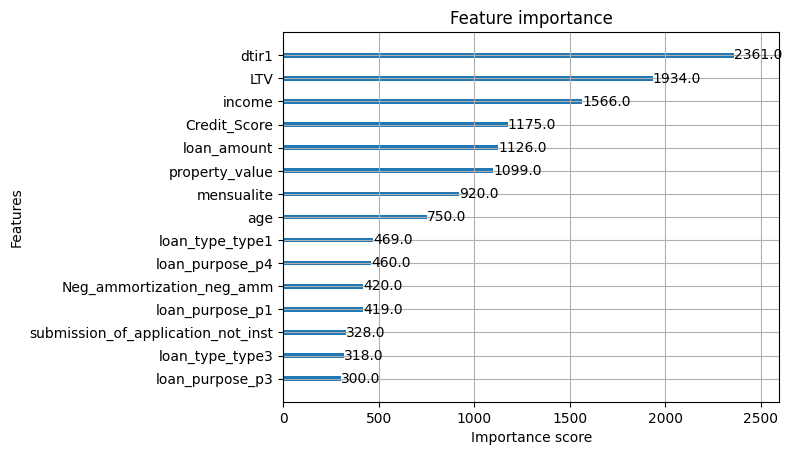

In [226]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Afficher les variables les plus importantes
plot_importance(xgb, max_num_features=15)
plt.show()

### Détection et Correction de la Fuite de Données (Data Leakage)

Lors des premières itérations, les modèles **XGBoost** et **Random Forest** affichaient un score **F1 de 1.0** (perfection suspecte). 

* **Analyse :** L'examen de l'importance des variables (*Feature Importance*) a révélé que trois colonnes — `rate_of_interest`, `upfront_charges`, et `interest_rate_spread` — dominaient massivement les prédictions.

* **Problématique :** Ces variables sont des indicateurs financiers souvent finalisés *après* la décision d'octroi ou le défaut du prêt. Elles agissaient comme des "réponses" déguisées, empêchant le modèle d'apprendre de réels motifs prédictifs.

* **Action :** J'ai supprimé ces trois variables pour obtenir des scores réalistes (XGBoost ≈ 0.92, RF ≈ 0.85), garantissant ainsi que le modèle est capable de généraliser sur de nouvelles données clients.

---

### 4. Stratégie de Fine-Tuning

Je vais maintenant procéder à l'optimisation des hyperparamètres pour trois types de modèles afin de comparer l'équilibre entre **interprétabilité** et **performance brute** :

1.  **Modèle Linéaire (Baseline) :** * **Régression Logistique** : Choisi pour sa transparence et sa capacité à fournir des probabilités de défaut claires.

2.  **Modèles d'Ensemble (Complexes) :**
    * **Random Forest** : Pour sa robustesse face au bruit.

    * **XGBoost** : Mon modèle "Champion" actuel, qui offre la meilleure précision sur ce dataset complexe.

## Fine-tuning

### 1.  Logistic Regression : 

* **L1 (Lasso) :** Une punition qui peut forcer certains coefficients inutiles à devenir zéro (utile pour sélectionner les variables).

* **L2 (Ridge) :** Une punition qui réduit la taille des coefficients pour éviter que le modèle ne soit trop complexe.

* **C (Régularisation) :** Plus **C** est petit, plus la punition est forte (modèle simple) ; plus **C** est grand, plus le modèle essaie de coller aux données (risque d'overfitting).

In [227]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Définition de la grille de paramètres
# On teste différentes forces de régularisation
param_grid = [
    {'C': [0.01 , 0.1 , 1, 100, 1000], 'penalty': ['l2'], 'solver': ['lbfgs']},
]

# 2. Mise en place de GridSearchCV
# On utilise scoring='f1' car c'est ta métrique de référence
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# 3. Entraînement
grid_search.fit(X_train_resampled, y_train_resampled)

# 4. Meilleurs résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score F1 en CV : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   1.2s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   1.3s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   1.4s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   1.7s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   2.2s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   2.3s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   2.4s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   2.5s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   2.5s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   2.6s
[CV] END ......................C=1, penalty=l2, solver=lbfgs; total time=   2.3s
[CV] END ......................C=1, penalty=l2, s

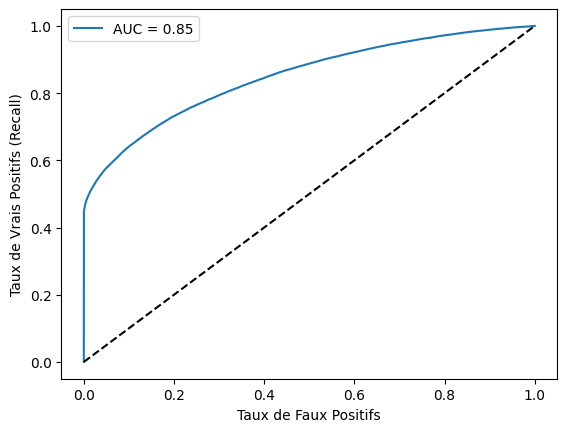

In [228]:
from sklearn.metrics import roc_curve, roc_auc_score

# Obtenir les probabilités (pas juste les classes 0 ou 1)
y_probs = log_reg.predict_proba(X_train_resampled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train_resampled, y_probs)
auc_score = roc_auc_score(y_train_resampled, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--') # Ligne de hasard
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.legend()
plt.show()

La configuration initiale est conservée, car les tests de régularisation ont entraîné une baisse des résultats.

### 2. Radom Forest : 

In [229]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False] # Avec ou sans remise
}

rf = RandomForestClassifier(random_state=42)

rnd_search_rf = RandomizedSearchCV(rf, param_dist_rf, n_iter=10, cv=3, 
                                   scoring='f1', n_jobs=-1, verbose=2)

rnd_search_rf.fit(X_train_resampled, y_train_resampled)

print("")
print("Meilleurs Paramètres :", rnd_search_rf.best_params_)
print("Meilleur Score F1 :", rnd_search_rf.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=False, max_depth=10, min_samples_split=5, n_estimators=200; total time=  28.2s
[CV] END bootstrap=False, max_depth=10, min_samples_split=5, n_estimators=200; total time=  28.9s
[CV] END bootstrap=False, max_depth=None, min_samples_split=5, n_estimators=100; total time=  29.7s
[CV] END bootstrap=False, max_depth=None, min_samples_split=5, n_estimators=100; total time=  29.9s
[CV] END bootstrap=False, max_depth=None, min_samples_split=5, n_estimators=100; total time=  30.2s
[CV] END bootstrap=False, max_depth=10, min_samples_split=5, n_estimators=200; total time=  32.0s
[CV] END bootstrap=True, max_depth=20, min_samples_split=5, n_estimators=200; total time=  36.3s
[CV] END bootstrap=True, max_depth=20, min_samples_split=5, n_estimators=200; total time=  35.3s
[CV] END bootstrap=True, max_depth=20, min_samples_split=5, n_estimators=200; total time=  35.5s
[CV] END bootstrap=False, max_depth=20, min_samples_sp

### Final Random Forest

In [230]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Créer le modèle final avec les "Meilleurs Paramètres"
final_rf = RandomForestClassifier(
    n_estimators=200, 
    min_samples_split=5, 
    max_depth=15, 
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


final_rf.fit(X_train_resampled, y_train_resampled)

y_test_pred = final_rf.predict(X_train_resampled)

print("--- PERFORMANCE FINALE (RANDOM FOREST) ---")
print(classification_report(y_train_resampled, y_test_pred))

--- PERFORMANCE FINALE (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     89625
           1       0.98      0.81      0.88     89625

    accuracy                           0.89    179250
   macro avg       0.91      0.89      0.89    179250
weighted avg       0.91      0.89      0.89    179250



### 3. XGBoost : 

Aucune régularisation n'a été appliquée car le modèle atteint déjà une performance optimale de 0.93.

### 4. Ensemble

### a. Voting

In [231]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
                estimators=[('lr', log_reg), ('rf', final_rf), ('xgb', xgb)],
                voting='soft',
            )

voting_clf.fit(X_train_resampled,y_train_resampled)

y_voting_pred = voting_clf.predict(X_train_resampled)

print("--- PERFORMANCE de l'ensemble ---")
print(classification_report(y_train_resampled, y_voting_pred))

--- PERFORMANCE de l'ensemble ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     89625
           1       0.97      0.85      0.91     89625

    accuracy                           0.91    179250
   macro avg       0.92      0.91      0.91    179250
weighted avg       0.92      0.91      0.91    179250



### b. Stacking

In [232]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(
    estimators=[
        ('lr', log_reg), ('rf', final_rf), ('xgb', xgb)
    ],
    final_estimator = LogisticRegression(),
    cv=3,
    n_jobs=-1
)

stack_clf.fit(X_train_resampled, y_train_resampled)

y_stack_pred = stack_clf.predict(X_train_resampled)

print("--- PERFORMANCE de l'ensemble ---")
print(classification_report(y_train_resampled, y_stack_pred))

--- PERFORMANCE de l'ensemble ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     89625
           1       0.96      0.89      0.92     89625

    accuracy                           0.93    179250
   macro avg       0.93      0.93      0.93    179250
weighted avg       0.93      0.93      0.93    179250



## Evaluation on the test set

In [233]:
X_train_preprocessed = full_pipeline.fit_transform(X_train_2)

X_test_pipe = full_pipeline.transform(X_test)[X_train.columns]


In [234]:
print("--- VERDICT FINAL : PERFORMANCE SUR LE TEST SET ---")

y_pred_xgb = xgb.predict(X_test_pipe)
print("---- XGBoost ----")
print(classification_report(y_test,y_pred_xgb))
print("")

y_pred_rf = final_rf.predict(X_test_pipe)
print("---- RandomForest ----")
print(classification_report(y_test,y_pred_rf))
print("")

y_pred_lr = log_reg.predict(X_test_pipe)
print("---- LogisticReg ----")
print(classification_report(y_test,y_pred_lr))
print("")

y_pred_vot = voting_clf.predict(X_test_pipe)
print("---- Ensemble ( voting ) ----")
print(classification_report(y_test,y_pred_vot))
print("")

y_pred_stack = stack_clf.predict(X_test_pipe)
print("---- Ensemble ( stacking )----")
print(classification_report(y_test,y_pred_vot))
print("")

--- VERDICT FINAL : PERFORMANCE SUR LE TEST SET ---
---- XGBoost ----
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     22406
           1       0.67      0.72      0.69      7328

    accuracy                           0.84     29734
   macro avg       0.79      0.80      0.79     29734
weighted avg       0.85      0.84      0.84     29734


---- RandomForest ----
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     22406
           1       0.84      0.64      0.73      7328

    accuracy                           0.88     29734
   macro avg       0.87      0.80      0.83     29734
weighted avg       0.88      0.88      0.88     29734


---- LogisticReg ----
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22406
           1       0.67      0.65      0.66      7328

    accuracy                           0.83     29734
   macro av

### 1. 🥇 Random Forest / Ensemble (F1 = 0.73)

### 2. 🥈 XGBoost (F1 = 0.69)

### 3. 🥉 Logistic Regression (F1 = 0.66)

Sur le jeu d'entraînement, l'XGBoost semblait être le roi incontesté (0.92). Mais c'était un piège : il a fait de l'overfitting (surapprentissage). Il a trop mémorisé les données artificielles créées par le SMOTE. Lorsqu'il a été confronté au vrai monde (le Test Set), ses performances ont lourdement chuté.

À l'inverse, le Random Forest s'est montré beaucoup plus robuste. Il a moins appris par cœur pendant l'entraînement, ce qui lui a permis de mieux "généraliser" sur les données inconnues du jeu de test. Le modèle Ensemble obtient le même score, prouvant que le Random Forest porte l'équipe sur ses épaules.

## Feature Importance

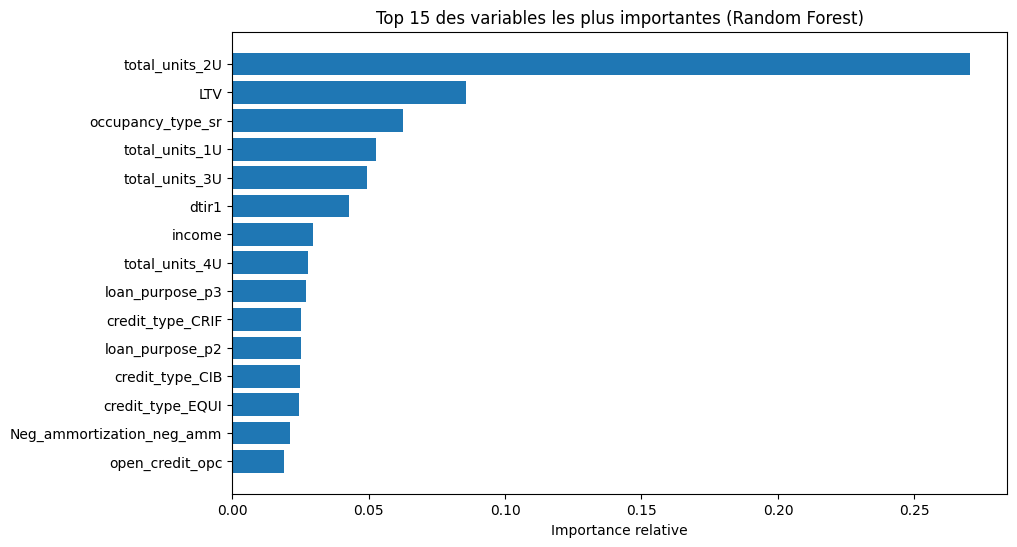

In [235]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Récupérer les noms des colonnes après le preprocessing
# (Grâce à ton set_config(transform_output="pandas"), c'est facile)
feature_names = X_train_preprocessed.columns

# 2. Récupérer les importances du modèle RF (ton champion)
importances = final_rf.feature_importances_

# 3. Créer un DataFrame pour faciliter le tri
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Afficher les 15 variables les plus importantes
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(15), feature_importance_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 des variables les plus importantes (Random Forest)")
plt.xlabel("Importance relative")
plt.show()

### 9. Analyse de l'Importance des Variables

Le graphique de Feature Importance de notre modèle **Random Forest** met en évidence les facteurs critiques influençant le score de crédit :

1.  **Structure de la propriété (`total_units`) :** Les propriétés à unités multiples semblent être le premier indicateur de segmentation du risque.

2.  **Ratios Financiers (`LTV`, `dtir1`) :** Le levier financier et le taux d'endettement sont, sans surprise, les piliers de la décision algorithmique.

3.  **Profil de Crédit (`credit_type`, `loan_purpose`) :** Le but du prêt et l'organisme de crédit source apportent une finesse supplémentaire à la prédiction.

**Conclusion :** Le modèle a appris des règles métier cohérentes avec les pratiques bancaires réelles, ce qui renforce notre confiance dans sa capacité à généraliser sur de nouveaux dossiers.

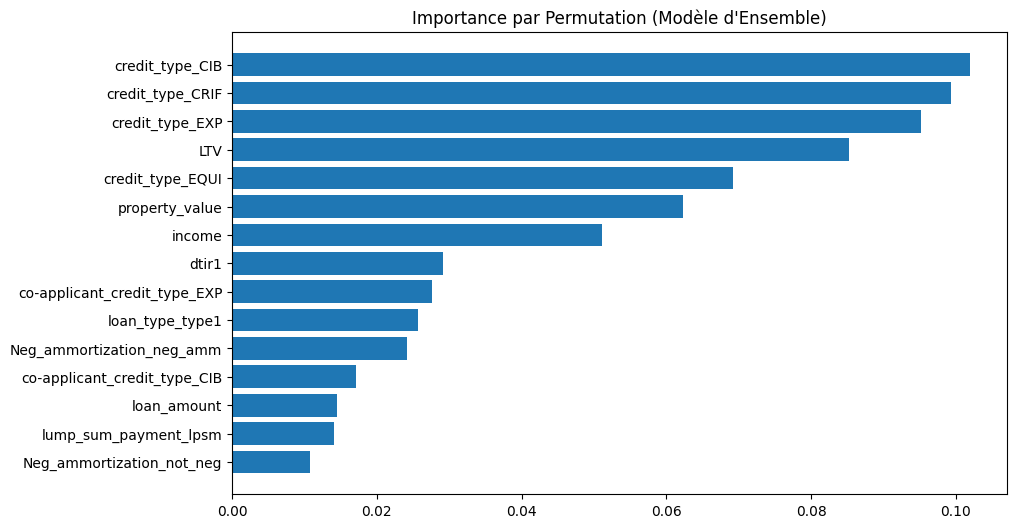

In [236]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    voting_clf, X_test_pipe, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Organiser les résultats
perm_importances_df = pd.DataFrame({
    'Feature': X_test_pipe.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_importances_df['Feature'].head(15), perm_importances_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Importance par Permutation (Modèle d'Ensemble)")
plt.show()

#### La méthode "Permutation Importance" (La plus précise) :

Le principe : On prend une colonne (ex: income), on mélange ses valeurs au hasard, et on regarde de combien le score du modèle chute. Si le score s'écroule, c'est que la variable était capitale.

## Time required !

In [237]:
end_time = time.time()
total_duration = end_time - start_time

print(f"--- Processus terminé en {int(total_duration // 60)} min {total_duration % 60:.2f} s ---")

--- Processus terminé en 6 min 18.53 s ---
